In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
import gc
from matplotlib import cm
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from scipy import linalg
from astropy.cosmology import Planck18
from astropy import constants as const

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [1]:
G_hi = 20.5

In [4]:
nthreads = 18

In [5]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [6]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
z_array = range(len(z_bins)-1)
mask = 0.5

In [7]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [8]:
Delta = 200
delta_c = 1.686

In [9]:
hmf = ccl.halos.MassFuncTinker10()

In [10]:
NSIDE = 64

In [11]:
M_max = 15

## Define functions

In [12]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [13]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [14]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_planck18):
    
    sigma = cosmo.sigmaM(M, a = a)
   
    return delta_c/sigma

In [15]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_planck18, hmf = hmf, recenter = True):

    if recenter == True:
        bins = quaia.recenter(bins)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
    n_g = np.trapz(n_g, bins)
    dn_dm = nm/(bins*np.log(10))

    b1_E_tinker = b1_E_func(nu(bins, a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [16]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [17]:
def cf_2h(bins, n_m, a, cosmo, cf_matter, recenter = True):
    
    b_q, n_g = bias(bins, n_m, a, cosmo, recenter = recenter)
    return b_q**2*cf_matter, b_q

In [18]:
def M(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True, hmf = hmf):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [19]:
def HOD(bins, M_min, fduty):

    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=M_min]=fduty

    return n_m

In [20]:
def n_DM(cosmo, a, M_min, hmf = hmf, M_max = M_max, N = 79): #16.8
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 #/u.Mpc**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.trapz(dn_dm, bins)

# Visualize the bolometric luminosity-redshift distribution

In [21]:
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

In [22]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
{'NAME': '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog', 'ABBRV': 'Quaia'}
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


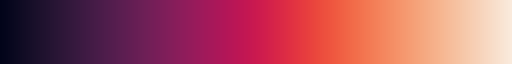

In [23]:
cmap = sns.color_palette("rocket", as_cmap=True)
cmap

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_22240/1836073741.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$L_\mathrm{bol}$ [erg $\mathrm{s}^{-1}]$')
/tmp/ipykernel_22240/1836073741.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$N_\mathrm{QSO}$')
/tmp/ipykernel_22240/1836073741.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('$N_\mathrm{QSO}$')


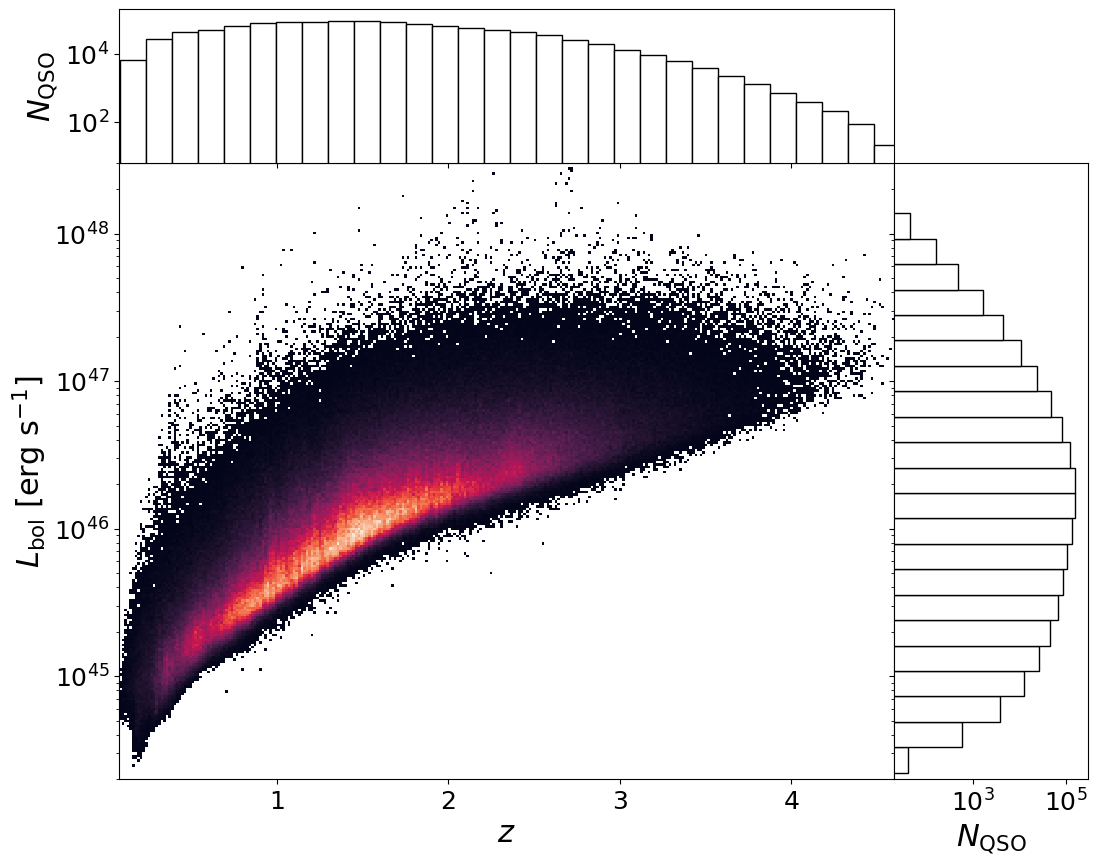

In [24]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.L_bol(tab_datahi)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['L_bol'][mask_datahi], cmap = cmap, 
                                       bins = [np.linspace(0.08, 4.6, 300), np.logspace(44, 49, 300)], cmin = 1)
ax1.set_ylabel('$L_\mathrm{bol}$ [erg $\mathrm{s}^{-1}]$')
ax1.set_xlabel('$z$')
ax1.set_ylim(2e44, 3e48)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()
ax1.set_yscale('log')

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = 'black', bins = 30)
ax2.set_ylabel('$N_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['L_bol'][mask_datahi], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = np.logspace(44, 49, 30))
ax3.set_xlabel('$N_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

In [25]:
colors = ['Red', 'Orange', 'Green', 'Blue', 'Purple']

In [26]:
L_bol = [44.5, 45.0, 45.5, 46.0, 46.5]

In [27]:
zbin_array = [0.0,1.0,2.0,3.0,4.6]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(L_bol)))

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_22240/95175934.py:24: SyntaxWarning: invalid escape sequence '\m'
  ax3.hist(tab_datahi_mask_zbin0['L_bol'], color = 'white', edgecolor = colors[i], orientation = 'horizontal', bins = np.logspace(44, 49, 30), alpha = 0.5, label = '$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[i]))
/tmp/ipykernel_22240/95175934.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$L_\mathrm{bol}$ [erg $\mathrm{s}^{-1}]$')
/tmp/ipykernel_22240/95175934.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$N_\mathrm{QSO}$')
/tm

G20.5_zmin0.0zmax1.0_Lbolmin44.5: 0.30              225780 vs 324311
G20.5_zmin0.0zmax1.0_Lbolmin45.0: 0.30              214489 vs 308126
G20.5_zmin0.0zmax1.0_Lbolmin45.5: 0.31              111779 vs 161096
G20.5_zmin0.0zmax1.0_Lbolmin46.0: 0.30              17294 vs 24716
G20.5_zmin0.0zmax1.0_Lbolmin46.5: 0.32              1549 vs 2271


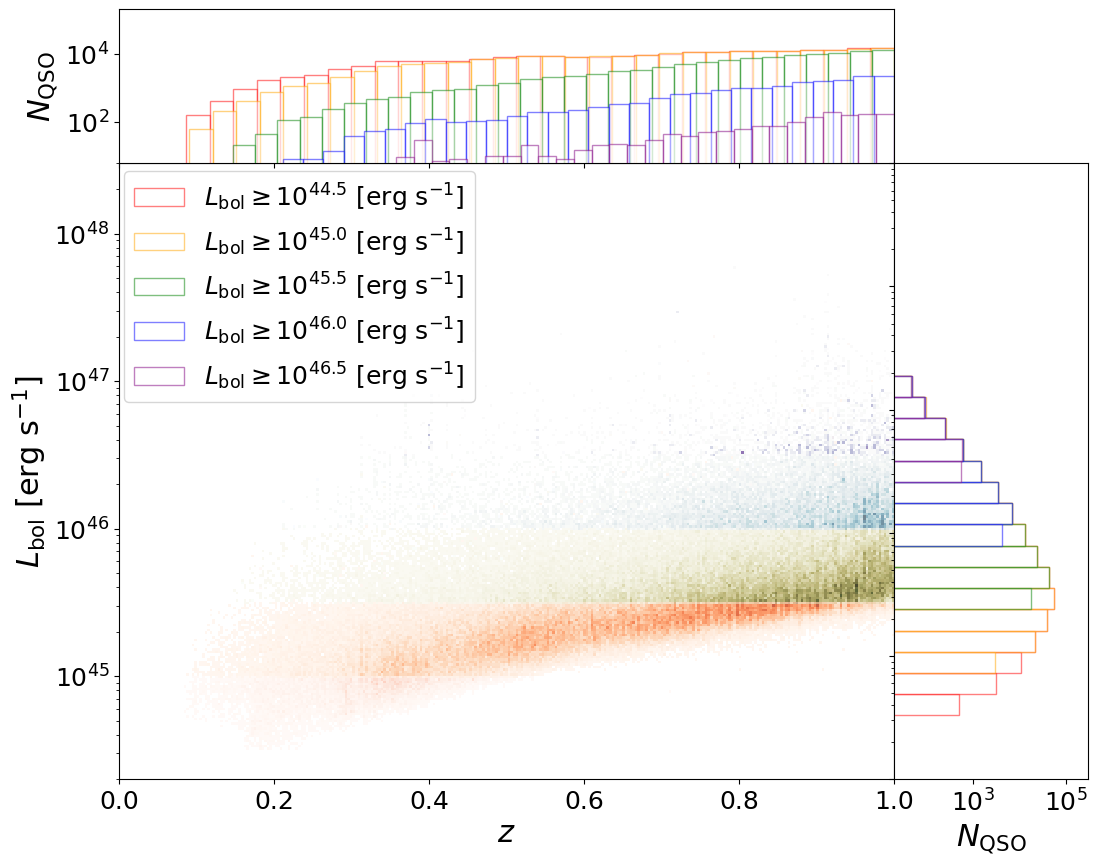

In [28]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)
fac_rand = 25

ax1 = fig.add_subplot(gs[2])
ax2 = fig.add_subplot(gs[0])
ax3 = fig.add_subplot(gs[3])

for i in range(len(L_bol)):
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _ = quaia.make_bins(G_hi, [0, i], True, ['z', 'L_bol'], 
                                                                                         bins = [zbin_array, L_bol], tab_gcat_type = 'data', 
                                                                                          method = ['minmax', 'threshold'], fac_rand = fac_rand, 
                                                                                          mask = mask*100, percentile = True, n_bins = [None, None])
    quaia.L_bol(tab_datahi_mask_zbin0)
    h1, xedges, yedges, image = ax1.hist2d(tab_datahi_mask_zbin0['redshift_quaia'], tab_datahi_mask_zbin0['L_bol'],
                                           cmap = plt.get_cmap('{}s'.format(colors[i])), bins = [np.linspace(0, 1, 300), np.logspace(44, 49, 300)],
                                           cmin = 1, alpha = 0.5)
    xlim = ax1.get_xlim()
    ylim = ax1.get_ylim()
    
    ax2.hist(tab_datahi_mask_zbin0['redshift_quaia'], color = 'white', edgecolor = colors[i], bins = 30, alpha = 0.5)
    ax3.hist(tab_datahi_mask_zbin0['L_bol'], color = 'white', edgecolor = colors[i], orientation = 'horizontal', bins = np.logspace(44, 49, 30), alpha = 0.5, label = '$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[i]))
    
ax1.set_ylabel('$L_\mathrm{bol}$ [erg $\mathrm{s}^{-1}]$')
ax1.set_xlabel('$z$')
ax1.set_ylim(2e44, 3e48)
ax1.set_yscale('log')

ax2.set_ylabel('$N_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3.set_xlabel('$N_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)
ax3.legend(loc = 'center right', bbox_to_anchor = (-2.1, 0.8)) #2, 0.75

plt.show()

## Visualize the bolometric luminosity-threshold cuts

In [29]:
mask_type = 'selfunc'

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_22240/1929363783.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax1.hist(tab_datahi_mask_zbin0['L_bol'], label = '$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[i]),
/tmp/ipykernel_22240/1929363783.py:32: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('$L_\mathrm{bol}$ [erg $\mathrm{s}^{-1}]$')
/tmp/ipykernel_22240/1929363783.py:33: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$N_\mathrm{QSO}$')


G20.5_zmin0.0zmax1.0_Lbolmin44.5: 0.30              225780 vs 324311
G20.5_zmin0.0zmax1.0_Lbolmin45.0: 0.30              214489 vs 308126
G20.5_zmin0.0zmax1.0_Lbolmin45.5: 0.31              111779 vs 161096
G20.5_zmin0.0zmax1.0_Lbolmin46.0: 0.30              17294 vs 24716
G20.5_zmin0.0zmax1.0_Lbolmin46.5: 0.32              1549 vs 2271


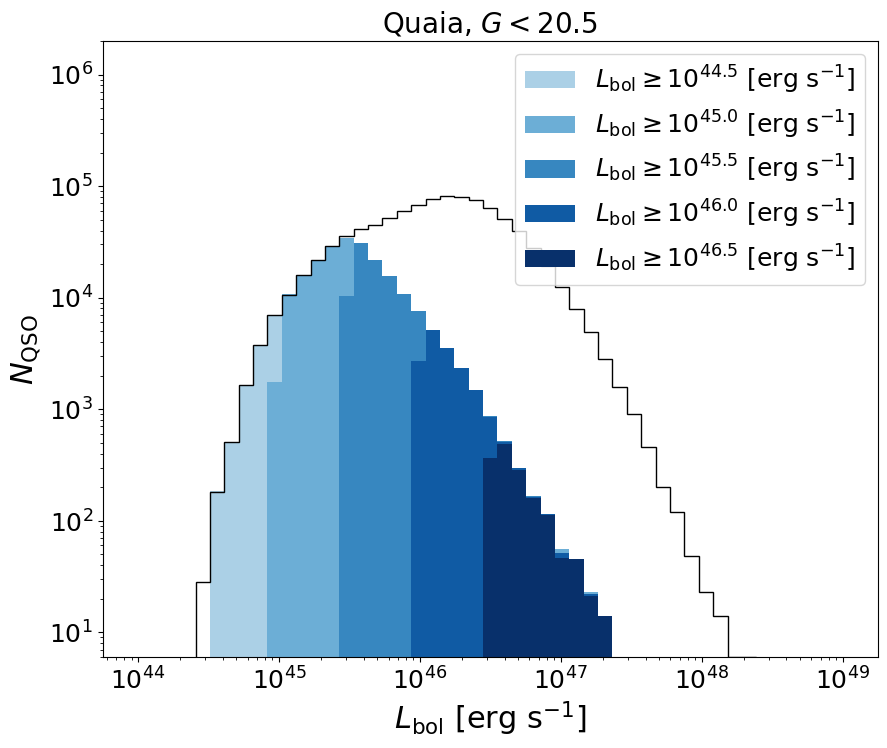

In [30]:
# plot data
bins = np.logspace(44, 49)
wp, rpavg = [], []
mask = 0.5
fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_hi)
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

fn_datahi = '../data/quaia_G{}.fits'.format(G_hi)
tab_datahi = Table.read(fn_datahi)
pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
mask_datahi = selfunc_hi[pixel_indices_datahi]>=np.percentile(selfunc_hi, mask*100)

# plot!
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1, wspace = 0)

ax1 = fig.add_subplot(gs[0])
quaia.L_bol(tab_datahi)
ax1.hist(tab_datahi['L_bol'][mask_datahi], bins=bins, histtype = 'step', color='black')

for i in range(len(L_bol)):
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _ = quaia.make_bins(G_hi, [0, i], True, ['z', 'L_bol'], 
                                                                                         bins = [zbin_array, L_bol], tab_gcat_type = 'data', 
                                                                                          method = ['minmax', 'threshold'], fac_rand = fac_rand, 
                                                                                          mask = mask*100, percentile = True, n_bins = [None, None])
    quaia.L_bol(tab_datahi_mask_zbin0)
    # quaia.L_bol(tab_randhi_mask_zbin0)
    ax1.hist(tab_datahi_mask_zbin0['L_bol'], label = '$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[i]), 
             bins = bins, color = cmap_blue[i])

ax1.set_xlabel('$L_\mathrm{bol}$ [erg $\mathrm{s}^{-1}]$')
ax1.set_ylabel('$N_\mathrm{QSO}$')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim(6,2e6)
ax1.set_title('Quaia, $G<{}$'.format(G_hi))
ax1.legend()

plt.show()

# Implement halo model
## Plot HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$
### At fixed $f_{duty}$ and $M_{min}$

In [31]:
bins = np.logspace(9, M_max, 79)
M_min = 12.8

In [32]:
M_min_array = [12.86, 12.74, 12.79, 12.82]

In [33]:
fduty = [0.018, 0.022, 0.056, 0.071]
n_m_array = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_m_array.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_22240/3618045427.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_22240/3618045427.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


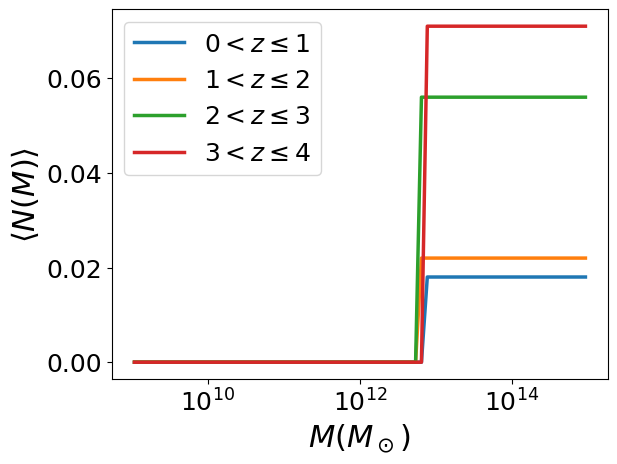

In [34]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))

plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

In [35]:
n_m_array, bins_M_min = [], []
for i in range(len(L_bol)):   
    bins_i = np.logspace(M_min_array[0], M_max, 79)
    n_m=np.ones(np.shape(bins_i))*fduty[0]
    n_m_array.append(n_m)
    bins_M_min.append(bins_i)

In [36]:
n_m_array_2D = []
for i in range(len(L_bol)):   

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.ones(np.shape(bins))*fduty[0]
        n_m_array_2D[i].append(n_m)

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [37]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), M_max, 79) for j in range(len(bins))]

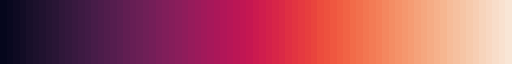

In [38]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

# Calculate derived parameters
## Plot b(z)

In [39]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_planck18): #quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [40]:
b_cf20 = np.load('../results/b_cf20_planck18.npy')
b_wp20 = np.load('../results/b_wp20_planck18.npy')

## Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [41]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
for i in range(len(L_bol)):
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0, _ = quaia.make_bins(G_hi, [0, i], True, ['z', 'L_bol'], 
                                                                                         bins = [zbin_array, L_bol], tab_gcat_type = 'data', 
                                                                                          method = ['minmax', 'threshold'], fac_rand = fac_rand, 
                                                                                          mask = mask*100, percentile = True, n_bins = [None, None])
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

G20.5_zmin0.0zmax1.0_Lbolmin44.5: 0.30              225780 vs 324311
G20.5_zmin0.0zmax1.0_Lbolmin45.0: 0.30              214489 vs 308126
G20.5_zmin0.0zmax1.0_Lbolmin45.5: 0.31              111779 vs 161096
G20.5_zmin0.0zmax1.0_Lbolmin46.0: 0.30              17294 vs 24716
G20.5_zmin0.0zmax1.0_Lbolmin46.5: 0.32              1549 vs 2271


In [42]:
n_q, n_q_err, V_eff, N_q = [], [], [], []

for j in range(len(L_bol)):
    
    N = len(tab_datahi_mask_zbins[j])
    cp = np.percentile(selfunc_hi_bins[j], mask*100)
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_hi_bins[j]>=cp]*hp.nside2pixarea(NSIDE))
    print(f_sky) # f_sky)
    V = f_sky*(Planck18.comoving_volume(1)-Planck18.comoving_volume(0))*cosmo_planck18['h']**3/u.h**3
    
    N_q.append(N)
    n_q.append(N/V.value)
    n_q_err.append(np.sqrt(N)/V.value) # Poisson error
    V_eff.append(V)

0.2975756970741422
0.2958458700265201
0.28045408337453476
0.3304692682051952
0.9699201423760125


In [43]:
fduty_err_hi = 0.002, 0.001, 0.008, 0.077
fduty_err_lo = 0.002, 0.001, 0.007, 0.034

In [44]:
def n_q_theory_err(n_dm, fduty_err, M_min, a, M_min_err, hmf = hmf, cosmo = cosmo_planck18): #quaia):
    
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.sqrt(n_dm**2*fduty_err**2+(fduty_err*hmf(cosmo, 10**M_min, a))**2*M_min_err**2)

# Perform $\chi^2$ fit
## $\chi_c^2=\sum \frac{\left(O_i-E_i\right)^2}{\sigma_i^2}$

### Enforce a hard limit on $n_q$

In [45]:
def f0(x, a, cf_matter, yerr_cf, cf, cosmo = cosmo_planck18): #quaia):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
        
    cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)
    
    return np.sum((cf-cf_2h_zbin)**2/yerr_cf**2)

### Add a number density constraint

In [46]:
def constraint(x, a, n_q, cosmo = cosmo_planck18, error = 0.05):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]

    return error-np.abs(n_q_theory-n_q)/n_q

## Limit scales to $30\geq s \geq 80h^{-1}$ Mpc

### Use the sigma directly

In [47]:
def f0_GLS(x, a, cf_matter, C, cf, n_q, cosmo = cosmo_planck18, error = 0.05, constraint = True):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
        
    cf_2h_zbin, _ = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)

    if constraint == False:
        n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]
        penalty = (n_q_theory-n_q)**2/(error*n_q)
    else:
        penalty = 0
        
    return (cf-cf_2h_zbin).T @ np.linalg.inv(C) @ (cf-cf_2h_zbin)+penalty

### Use this form of the loss function: $\chi_c^2={\Delta^TC^{-1}}\Delta$

In [48]:
def f0_GLS_solve(x, a, wp_matter, C, wp, rpbins, pibins, cosmo = cosmo_planck18, rpmask = True):  #quaia):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
        
    wp_2h_zbin, b_q = wp_2h(bins_m, n_m, a, cosmo, wp_matter, rpbins, pibins, recenter = False)
    
    if isinstance(rpmask, bool):
        rpmask = [rpmask]*len(quaia.recenter(rpbins))
    delta = (wp-wp_2h_zbin)[rpmask]
        
    return delta.T @ np.linalg.solve(C, delta)

## Use the full covariance matrix
### Include some bins we aren't analyzing

In [49]:
# Create the bins array
offset = 2.5
delta_max = 64
delta_min = np.min((np.floor((30-0.15)/offset), delta_max))

rmin = 30-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 80+delta_max*offset # 200
nbins = 20 + int(delta_min+delta_max) #90 #20
rbins_chi2 = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins_chi2, quaia.recenter(rbins_chi2), np.diff(quaia.recenter(rbins_chi2))

(array([  2.5,   5. ,   7.5,  10. ,  12.5,  15. ,  17.5,  20. ,  22.5,
         25. ,  27.5,  30. ,  32.5,  35. ,  37.5,  40. ,  42.5,  45. ,
         47.5,  50. ,  52.5,  55. ,  57.5,  60. ,  62.5,  65. ,  67.5,
         70. ,  72.5,  75. ,  77.5,  80. ,  82.5,  85. ,  87.5,  90. ,
         92.5,  95. ,  97.5, 100. , 102.5, 105. , 107.5, 110. , 112.5,
        115. , 117.5, 120. , 122.5, 125. , 127.5, 130. , 132.5, 135. ,
        137.5, 140. , 142.5, 145. , 147.5, 150. , 152.5, 155. , 157.5,
        160. , 162.5, 165. , 167.5, 170. , 172.5, 175. , 177.5, 180. ,
        182.5, 185. , 187.5, 190. , 192.5, 195. , 197.5, 200. , 202.5,
        205. , 207.5, 210. , 212.5, 215. , 217.5, 220. , 222.5, 225. ,
        227.5, 230. , 232.5, 235. , 237.5, 240. ]),
 array([  3.75,   6.25,   8.75,  11.25,  13.75,  16.25,  18.75,  21.25,
         23.75,  26.25,  28.75,  31.25,  33.75,  36.25,  38.75,  41.25,
         43.75,  46.25,  48.75,  51.25,  53.75,  56.25,  58.75,  61.25,
         63.75,  66.25

In [50]:
pimax = 80 # 40 # 5000.0 # 40.0

In [51]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

In [52]:
H0 = cosmo_planck18['H0'] * 100 * u.km/u.s/u.Mpc

In [53]:
wp_chi2, wp_matter_chi2, rpavg_chi2 = [], [], []
b_wp_chi2 = []
a_zbin, b_wp_q = [], []
rpmask = []
    
for i in range(len(L_bol)):
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0, _ = quaia.make_bins(G_hi, [0, i], True, ['z', 'L_bol'], 
                                                                                         bins = [zbin_array, L_bol], tab_gcat_type = 'data', 
                                                                                          method = ['minmax', 'threshold'], fac_rand = fac_rand, 
                                                                                          mask = mask*100, percentile = True, n_bins = [None, None])

    # quasar correlation function
    wp_zbin_i, rpavg_zbin_i = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                                                                  rbins = rbins_chi2, nbins = nbins , pimax = pimax, Om0 = cosmo_planck18['Omega_m'], h = cosmo_planck18['h'])
    wp_chi2.append(wp_zbin_i)
    rpavg_chi2.append(rpavg_zbin_i)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin.append(a)

    # matter correlation function   
    s = np.sqrt(np.sum(np.meshgrid(np.array(rpavg_zbin_i)**2, quaia.recenter(pibins)**2), axis = 0))
    s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
        
    xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo_planck18, r=np.ravel(s_Mpc), a=a_median(tab_datahi_mask_zbin0))
    wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)
    wp_matter_chi2.append(wp_matter_zbin_i)        

    # effective bias 
    b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
    b_wp_chi2.append(b)

    # qso bias
    b_wp_q.append(b_qso(wp_zbin_i, wp_matter_zbin_i, ccl.growth_rate(cosmo_planck18, a)))
    
    rpmask.append((np.array(rpavg_zbin_i) >= 30) & (np.array(rpavg_zbin_i) <= 80))

G20.5_zmin0.0zmax1.0_Lbolmin44.5: 0.30              225780 vs 324311


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_22240/1060848157.py:32: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_22240/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin0.0zmax1.0_Lbolmin45.0: 0.30              214489 vs 308126


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_22240/1060848157.py:32: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_22240/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin0.0zmax1.0_Lbolmin45.5: 0.31              111779 vs 161096


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin0.0zmax1.0_Lbolmin46.0: 0.30              17294 vs 24716


/tmp/ipykernel_22240/1060848157.py:32: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_22240/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin0.0zmax1.0_Lbolmin46.5: 0.32              1549 vs 2271


/tmp/ipykernel_22240/1060848157.py:32: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_22240/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_22240/1060848157.py:32: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_22240/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


## Solve for $\chi^2=\Delta^T x$ where $Cx=\Delta$

In [54]:
def wp_2h(bins, n_m, a, cosmo, wp_matter_zbin_i, rpbins, pibins, recenter = True, rpmask = True):

    if not isinstance(wp_matter_zbin_i, np.ndarray):
        
        print('computing wp_matter')
        
        # matter correlation function    
        if isinstance(rpmask, bool):
            rpmask = [rpmask]*len(quaia.recenter(rpbins))
            
        s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)[rpmask]**2, quaia.recenter(pibins)**2), axis = 0))
        s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(cosmo['h']* 100 * u.km/u.s/u.Mpc))

        xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo, r=np.ravel(s_Mpc), a=a)
        wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)

    return cf_2h(bins, n_m, a, cosmo, wp_matter_zbin_i, recenter = recenter)

In [55]:
error = [0.05, 0.05, 0.05, 0.05, 0.05]
res, M_min_fit, fduty_fit = [], [], []
for j in range(len(L_bol)):
    
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z0.0_Lbolmin{:.1f}_N25_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, L_bol[j]))    
    
    ix_grid = np.ix_(rpmask[j], rpmask[j])
    fun = lambda x: f0_GLS_solve(x, a_zbin[j], wp_matter_chi2[j], C[ix_grid], wp_chi2[j], rbins_chi2, pibins, rpmask = rpmask[j])
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[j], n_q[j], error = error[j])}) 
    
    res.append(minimize(fun, [fduty[0], M_min_array[0]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

/tmp/ipykernel_22240/2313523635.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_22240/2313523635.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


(array([12.86      , 12.86      , 10.82844631, 12.86      , 12.85885637]),
 array([-1.74472749, -1.74472749, -0.27177963, -1.74472749, -1.74484591]),
 [ message: Inequality constraints incompatible
   success: False
    status: 4
       fun: 38762858825.87096
         x: [ 1.800e-02  1.286e+01]
       nit: 1
       jac: [ 1.024e+03  8.547e+10]
      nfev: 3
      njev: 1,
   message: Inequality constraints incompatible
   success: False
    status: 4
       fun: 25381611749.64213
         x: [ 1.800e-02  1.286e+01]
       nit: 1
       jac: [-5.120e+02  5.619e+10]
      nfev: 3
      njev: 1,
   message: Inequality constraints incompatible
   success: False
    status: 4
       fun: 786010235.4990555
         x: [ 5.348e-01  1.083e+01]
       nit: 3
       jac: [ 4.000e+01  7.752e+08]
      nfev: 7
      njev: 2,
   message: Inequality constraints incompatible
   success: False
    status: 4
       fun: 169043595.61748004
         x: [ 1.800e-02  1.286e+01]
       nit: 1
       jac: [-

In [56]:
for j in range(len(L_bol)):
    
    print('L>={} erg/s'.format(L_bol[j]))
    x = fduty_fit[j], np.log10(M_min_fit[j])
    
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z0.0_Lbolmin{:.1f}_N25_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, L_bol[j]))    
    ix_grid = np.ix_(rpmask[j], rpmask[j])
    chi2 = f0_GLS_solve(x, a_zbin[j], wp_matter_chi2[j], C[ix_grid], wp_chi2[j], rbins_chi2, pibins, rpmask = rpmask[j])
    df = nbins-len(x)
    
    print('           chi^2: {:.2f}'.format(chi2))
    print('   reduced chi^2: {:.2f}'.format(chi2/df))
    print('         delta n: {:.2e}'.format(constraint(x, a_zbin[j], n_q[j], error = error[j])))
    try:
        print('condition number: {:.2f}'.format(np.linalg.cond(C)))
    except:
        print('condition number: SVD did not converge')
    print('             PTE: {:.2e}\n'.format(stats.chi2.sf(chi2, df)))

L>=44.5 erg/s
           chi^2: 38762858825.87
   reduced chi^2: 416804933.61
         delta n: 4.88e-02
condition number: 17327490005125437440.00
             PTE: 0.00e+00

L>=45.0 erg/s
           chi^2: 25381611749.64
   reduced chi^2: 272920556.45
         delta n: 1.57e-02
condition number: 4115194711448820224.00
             PTE: 0.00e+00

L>=45.5 erg/s
           chi^2: 786010235.50
   reduced chi^2: 8451722.96
         delta n: -6.01e+03
condition number: 4433793589152132096.00
             PTE: 0.00e+00

L>=46.0 erg/s
           chi^2: 169043595.62
   reduced chi^2: 1817673.07
         delta n: -1.19e+01
condition number: 37359849412186112000.00
             PTE: 0.00e+00

L>=46.5 erg/s
           chi^2: 2568894.43
   reduced chi^2: 27622.52
         delta n: -4.20e+02
condition number: SVD did not converge
             PTE: 0.00e+00



In [57]:
fduty_array = np.logspace(-5,0, 51) #-4

In [58]:
chi2_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in range(len(L_bol))}
cons_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in range(len(L_bol))}
for j in range(len(L_bol)):

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
            
            x = fduty_array[k], np.log10(bins[l])

            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z0.0_Lbolmin{:.1f}_N25_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, L_bol[j]))    
            ix_grid = np.ix_(rpmask[j], rpmask[j])

            chi2_m = f0_GLS_solve(x, a_zbin[j], wp_matter_chi2[j], C[ix_grid], wp_chi2[j], rbins_chi2, pibins, rpmask = rpmask[j])
            chi2_grid[j][l,k]=chi2_m
            cons = constraint(x, a_zbin[j], n_q[j], error = error[j])
            cons_grid[j][l,k]=cons

/tmp/ipykernel_22240/2313523635.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_22240/2313523635.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


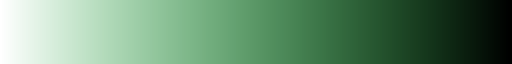

In [59]:
cmap_chi2 = sns.cubehelix_palette(start=2, rot=0, dark=0, light=1, as_cmap=True)
cmap_chi2

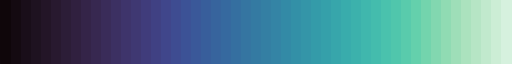

In [60]:
cmap_fduty = sns.color_palette("mako", n_colors = len(fduty_array))
palette_fduty = matplotlib.colors.ListedColormap(cmap_fduty)
palette_fduty

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_22240/676983591.py:8: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[j]))
/tmp/ipykernel_22240/676983591.py:10: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel('$\log_{

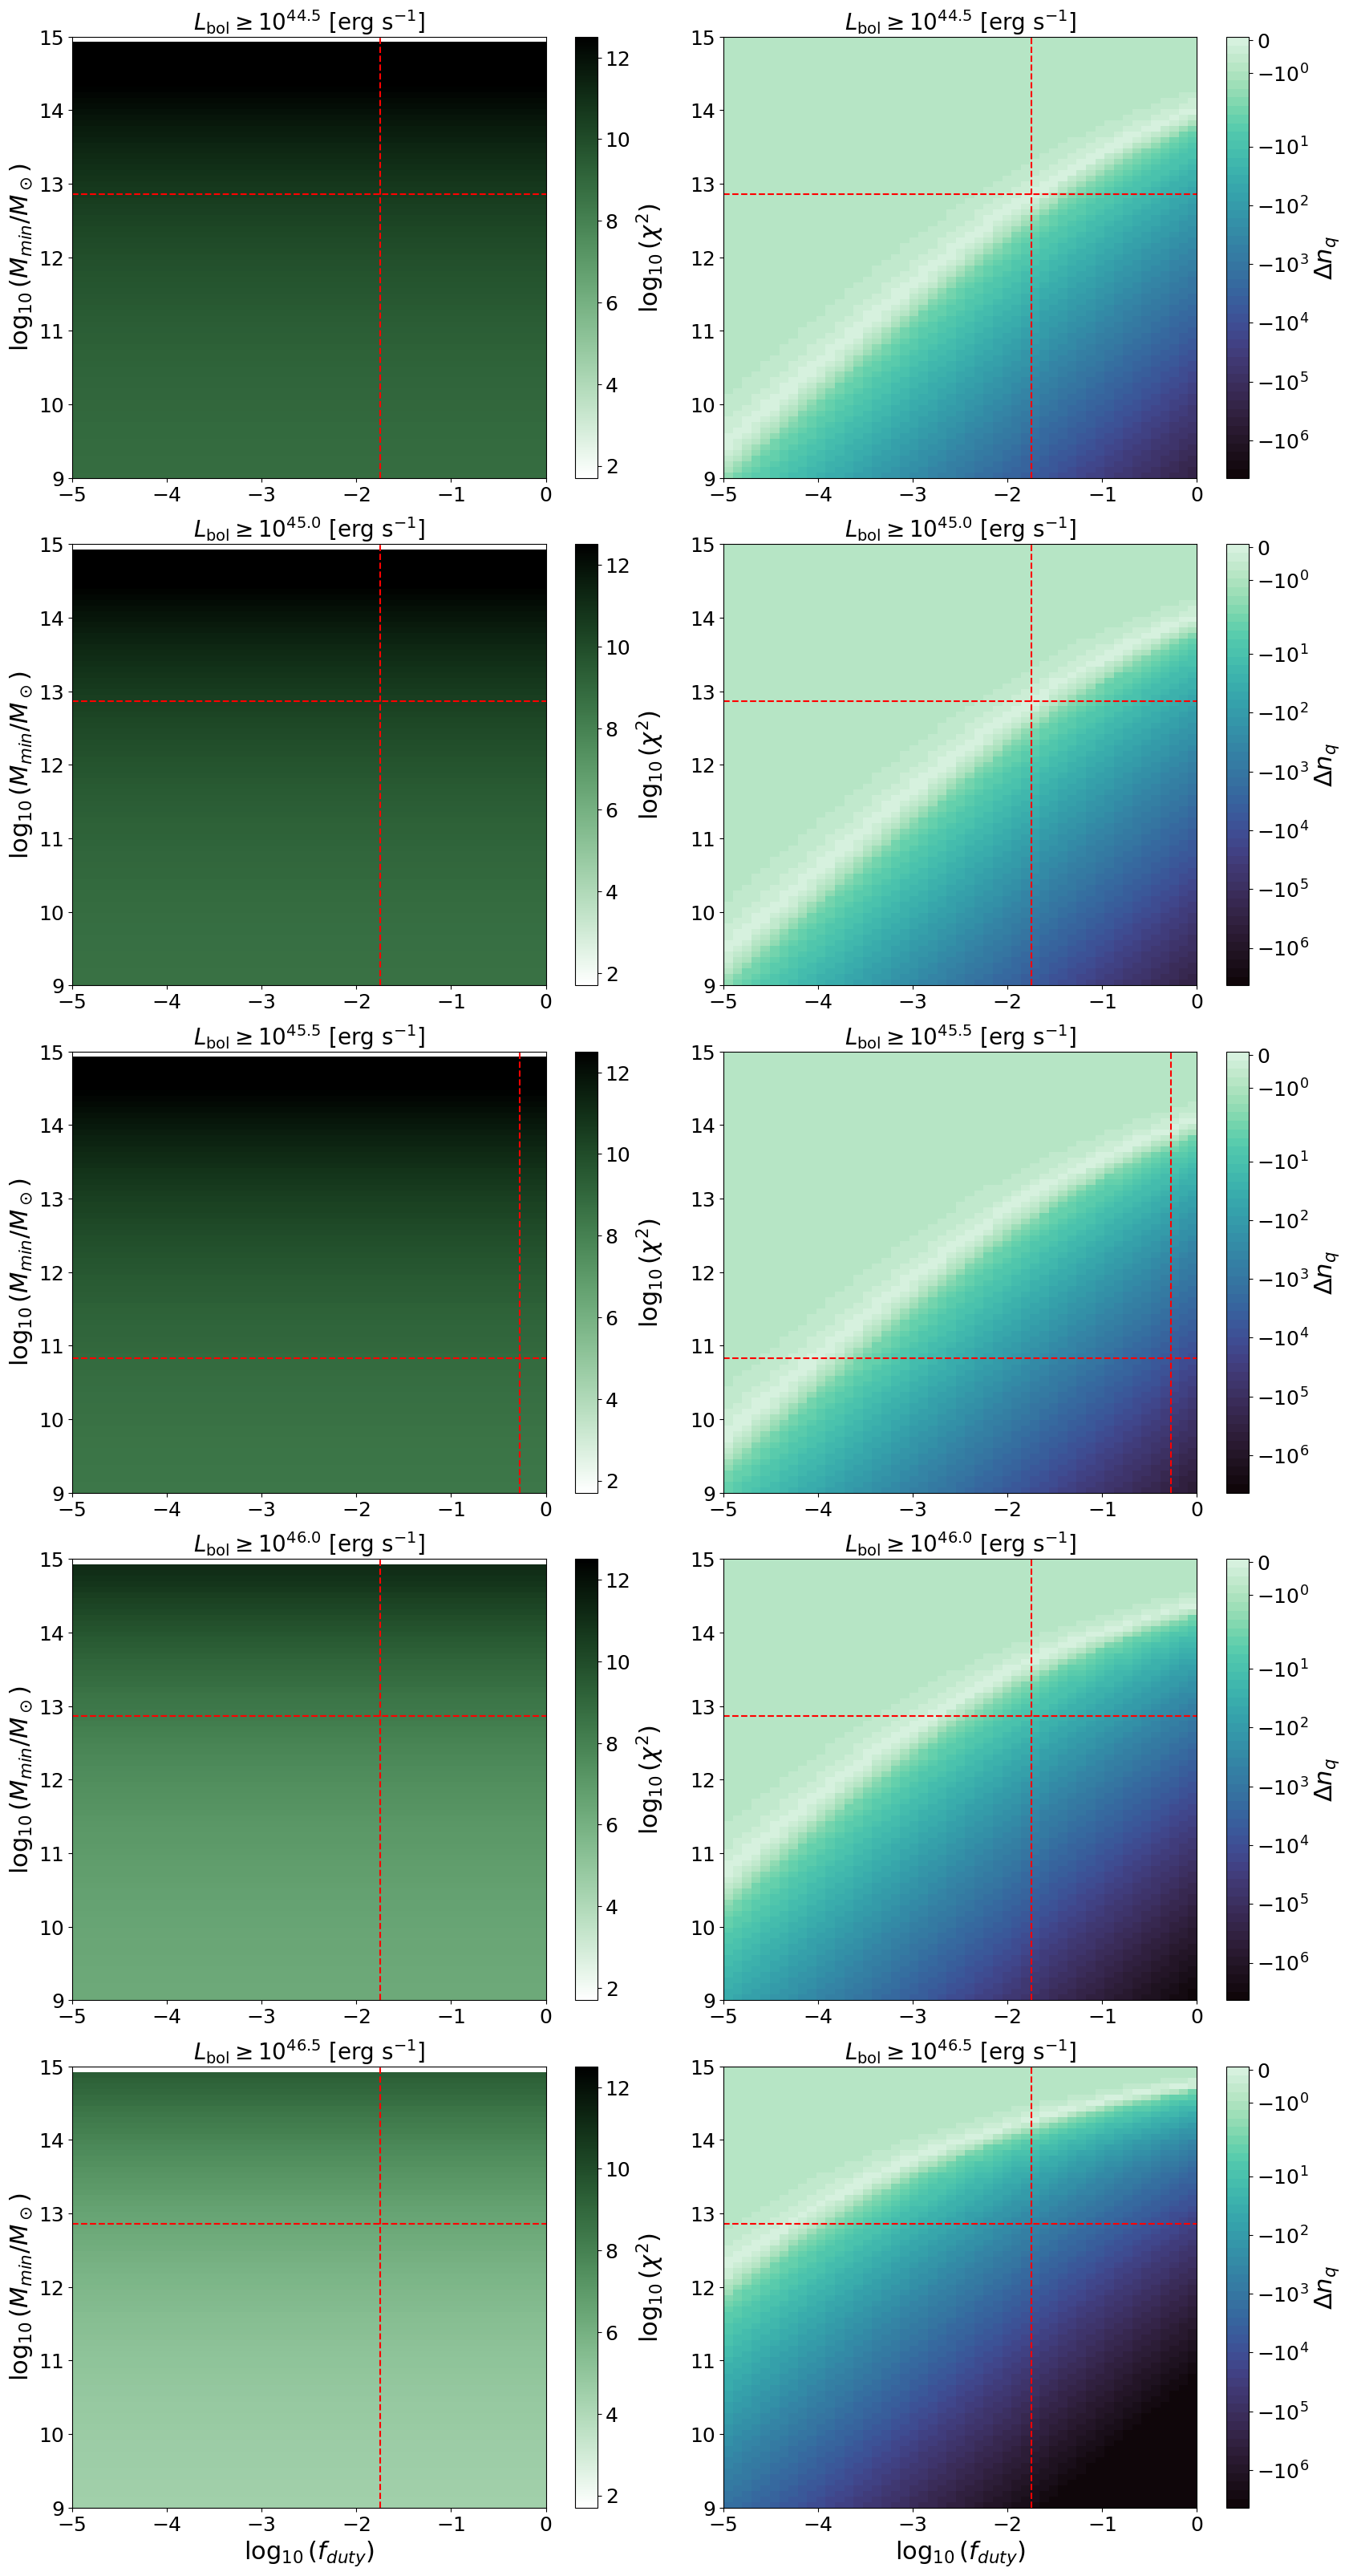

In [61]:
fig = plt.figure(figsize = (20, 40))
gs = gridspec.GridSpec(5, 2, hspace = 0.15, wspace = 0.1)

for j in range(len(L_bol)):
    
    ax1 = fig.add_subplot(gs[j*2])
    image = ax1.imshow(np.log10(chi2_grid[j]), cmap = cmap_chi2, vmin = np.log10(50.13706414974333), vmax = np.log10(3216118165719.2197), extent =  [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    ax1.set_title('$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[j]))
    if j == 4:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    ax1.set_ylabel('$\log_{10} (M_{min}/M_\odot)$')
    fig.colorbar(image, label='$\log_{10} (\chi^2)$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')
    
    ax1 = fig.add_subplot(gs[j*2+1])
    image = ax1.imshow(cons_grid[j], cmap = palette_fduty, norm = 'symlog', vmin = -4348491.828200184, vmax = 0.09959201649593023, extent = [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    ax1.set_title('$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[j]))
    if j == 4:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    fig.colorbar(image, label='$\Delta n_q$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')

plt.show()

## Plot results

In [62]:
zbin = 1/np.array(a_zbin)-1

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_22240/3432766316.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
/tmp/ipykernel_22240/3432766316.py:4: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')


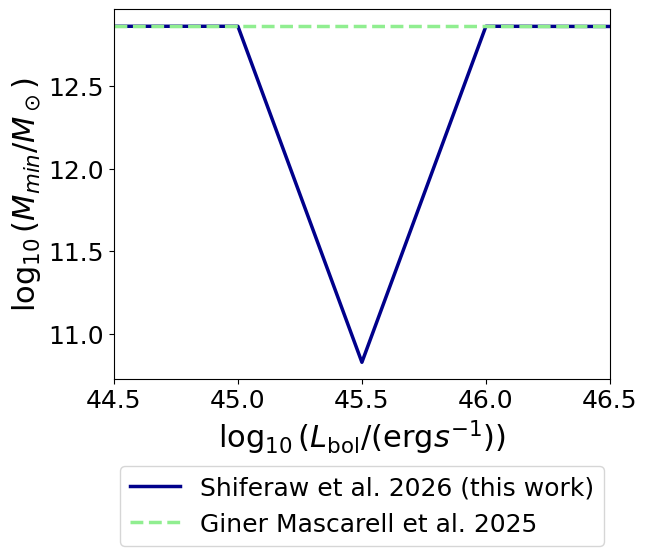

In [63]:
plt.plot(L_bol, np.log10(M_min_fit), color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.axhline(M_min_array[0], label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(L_bol[0], L_bol[-1])
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_22240/1055270469.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(f_{duty})$')
/tmp/ipykernel_22240/1055270469.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')


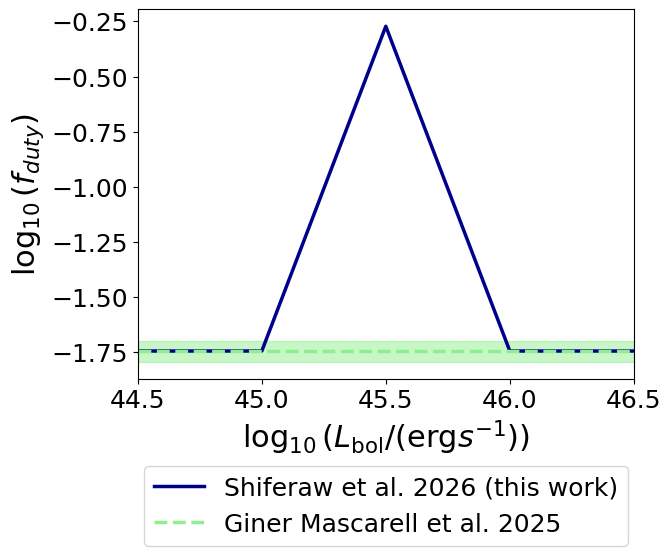

In [64]:
plt.plot(L_bol, np.log10(fduty_fit), color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(L_bol, [np.log10(fduty[0]+fduty_err_hi[0])]*len(L_bol), [np.log10(fduty[0]-fduty_err_lo[0])]*len(L_bol), alpha = 0.5, 
                 color = 'lightgreen')
plt.axhline(np.log10(fduty[0]), label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(L_bol[0], L_bol[-1])
plt.show()

In [65]:
b_eff_wp20 = np.load('../results/b_eff_wp20.npy')

## Pick cosmology

In [66]:
cosmo = 'Planck'

<>:63: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_22240/3505452058.py:63: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('$G<{}: L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(G_hi, L_bol[j]))


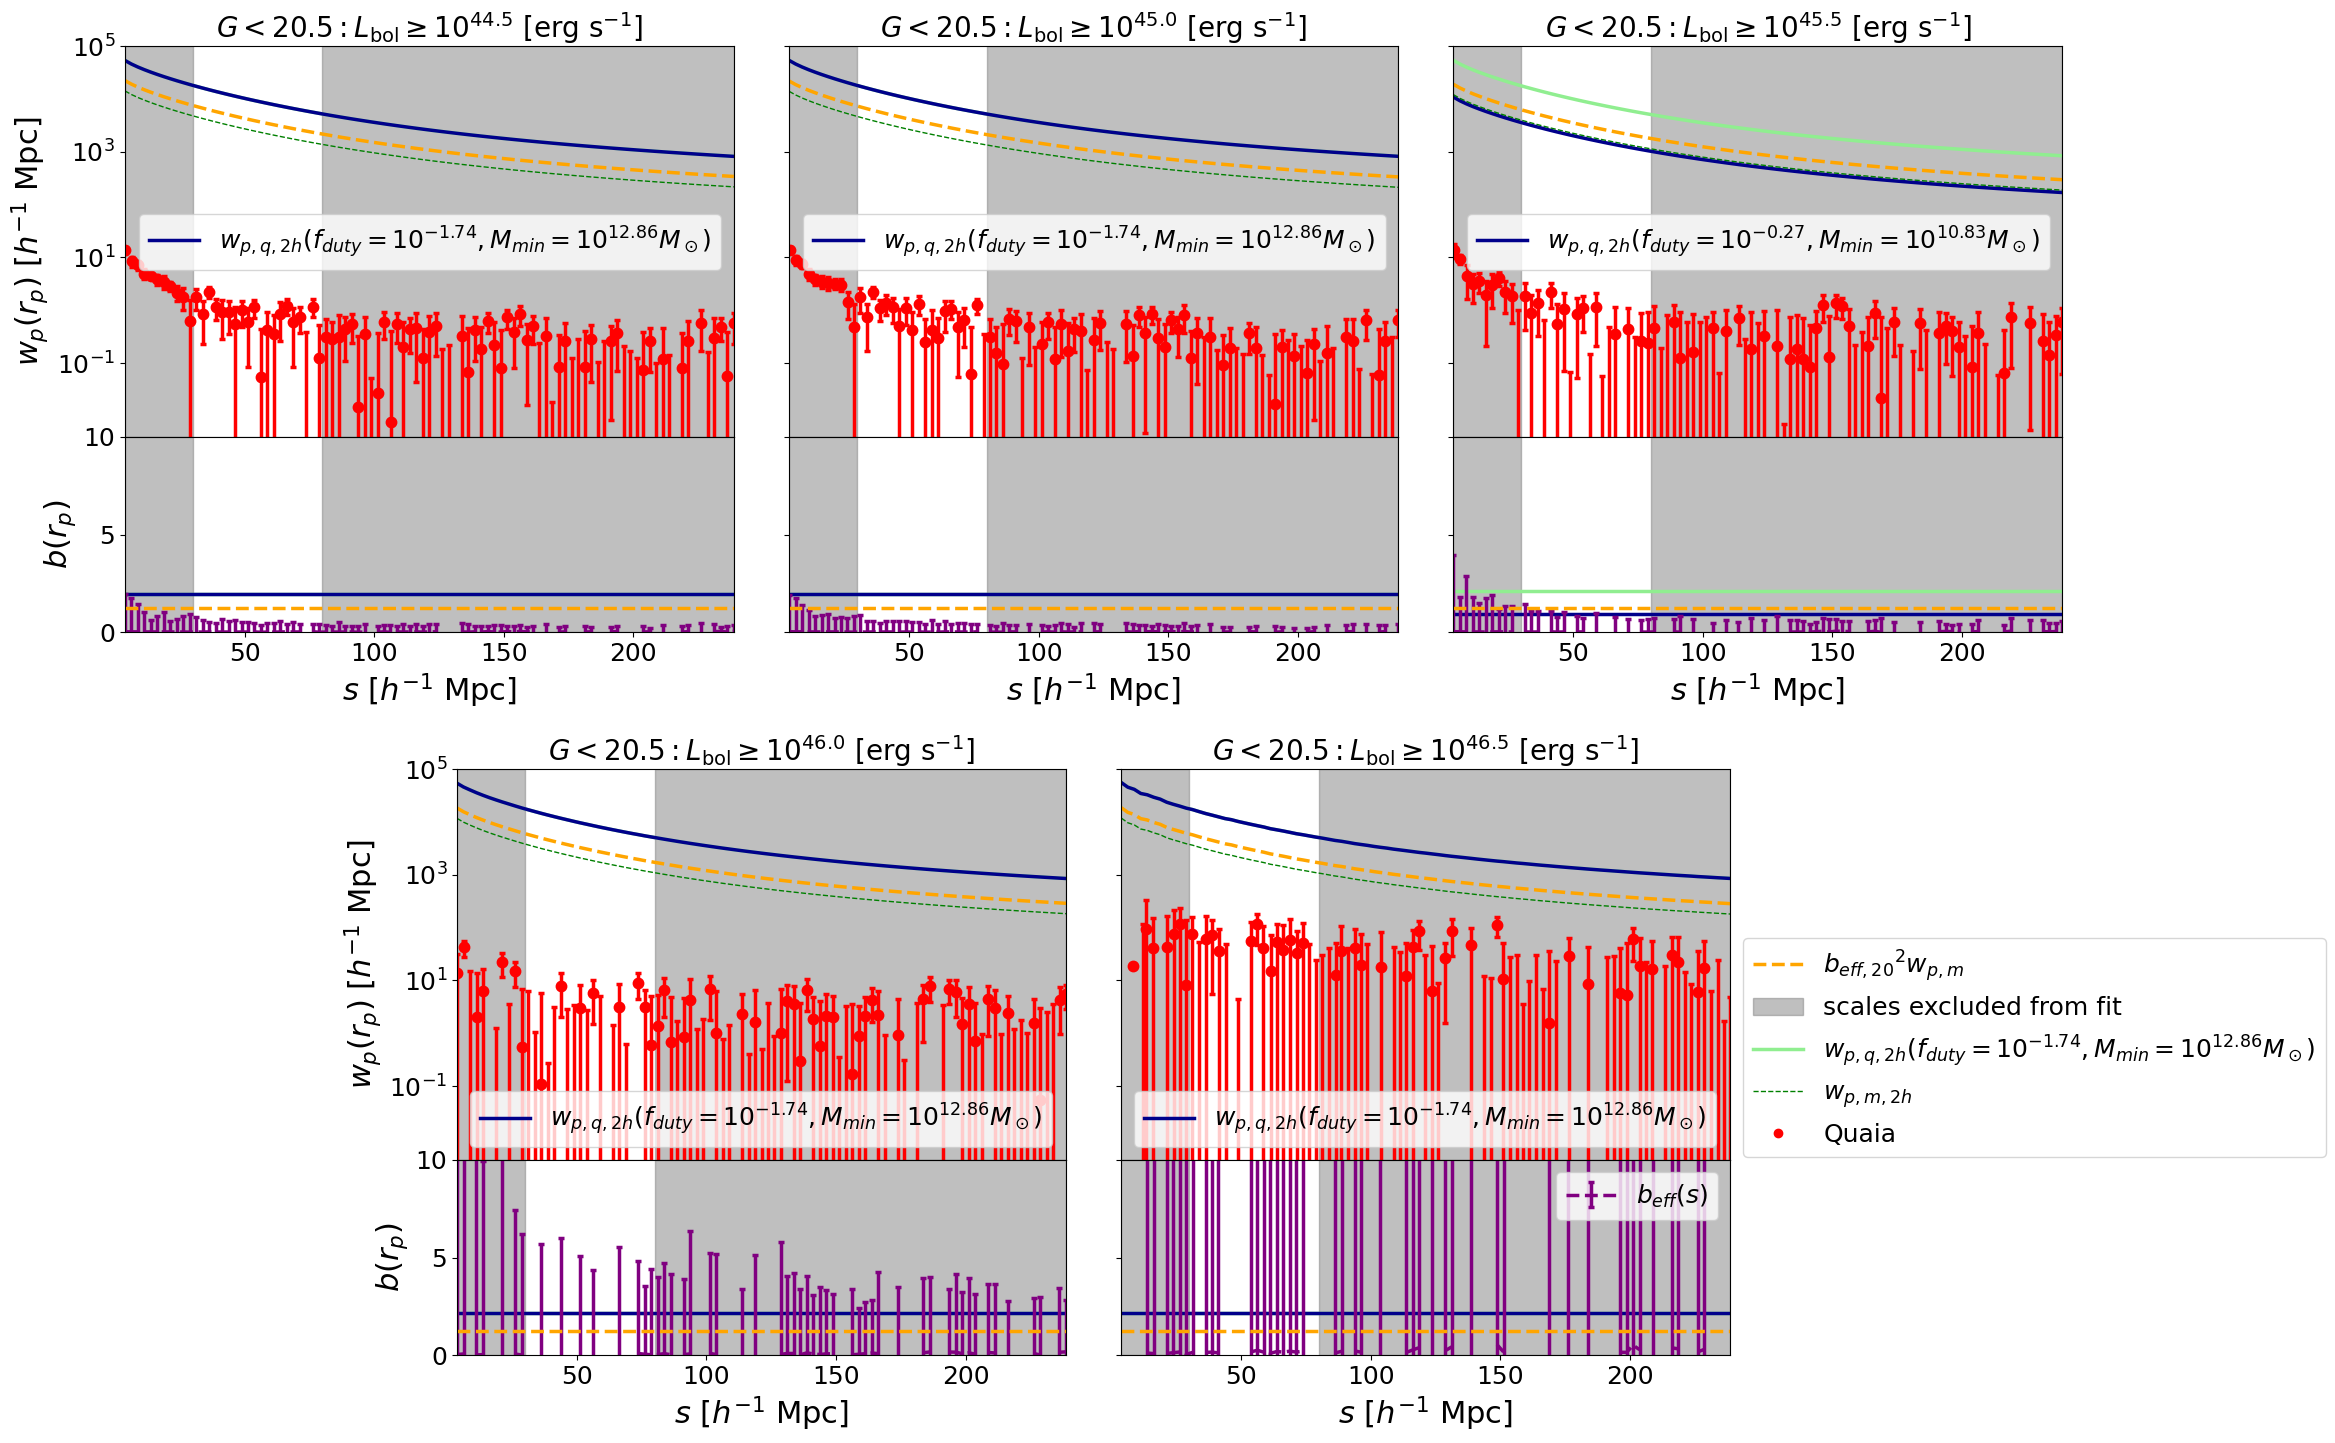

In [67]:
# plot!
fig = plt.figure(figsize = (25,17))  #13.5
grid = gridspec.GridSpec(5, 6, height_ratios = [1, 0.5, 0.35, 1, 0.5], hspace = 0) #0.25

ax1 = plt.subplot(grid[0, 0:2])
ax2 = plt.subplot(grid[0, 2:4])
ax3 = plt.subplot(grid[0, 4:6])
ax4 = plt.subplot(grid[3, 1:3])
ax5 = plt.subplot(grid[3, 3:5])
axlist = [ax1, ax2, ax3, ax4, ax5] #https://www.geeksforgeeks.org/matplotlib-gridspec-gridspec-class-in-python/

ax6 = plt.subplot(grid[1, 0:2])
ax7 = plt.subplot(grid[1, 2:4])
ax8 = plt.subplot(grid[1, 4:6])
ax9 = plt.subplot(grid[4, 1:3])
ax10 = plt.subplot(grid[4, 3:5])
axlist2 = [ax6, ax7, ax8, ax9, ax10] #https://www.geeksforgeeks.org/matplotlib-gridspec-gridspec-class-in-python/

ylim = 4e-3, 1e5
k = 0
for j in range(len(L_bol)):

    ax1 = axlist[j]
    ax2 = axlist2[j]
    
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z0.0_Lbolmin{:.1f}_N25_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, L_bol[j]))
            
    ax1.errorbar(rpavg_chi2[j], wp_chi2[j], linewidth = 2.5, marker = 'o', 
                 color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins_chi2), b_eff_wp20[0]**2*wp_matter_chi2[j], linewidth = 2.5,
             color = 'orange', linestyle = '--')
    ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5) # label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)

    # old fit
    wp_2h_zbin, b_q = wp_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins_chi2, pibins, recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), wp_2h_zbin, linewidth = 2.5, 
             color = 'lightgreen')
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*fduty_fit[j]
    wp_2h_zbin, b_q = wp_2h(np.logspace(np.log10(M_min_fit[j]),M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins_chi2, pibins,
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), wp_2h_zbin, linewidth = 2.5,
             label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty_fit[j]), 
                                                                                                        np.log10(M_min_fit[j])), 
             color = 'darkblue')
    ax1.plot(quaia.recenter(rbins_chi2), wp_matter_chi2[j], linewidth = 1, linestyle = '--', color = 'green')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')

    ax2.errorbar(quaia.recenter(rbins_chi2), b_wp_chi2[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    ax2.axhline(b_eff_wp20[0], linewidth = 2.5, color = 'orange', linestyle = '--')
    ax2.fill_betweenx(np.linspace(0, 10), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5)
    ax2.fill_betweenx(np.linspace(0, 10), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)
    
    ax1.set_title('$G<{}: L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(G_hi, L_bol[j]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(ylim)
    ax1.legend()

    ax2.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax2.set_ylim(0, 10)
    
    if (j == 0) or (j == 3):
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=4

custom_lines = [Line2D([0], [0], color = 'orange', linestyle = '--', linewidth = 2.5),
                mpatches.Patch(color='grey', alpha = 0.5),
                Line2D([0], [0], color = 'lightgreen', linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '--', linewidth = 1), 
                Line2D([0], [0], color = 'red', linestyle = 'none', marker = 'o', linewidth = 2.5)]
second_legend = ax2.legend(custom_lines, [r'${b_{eff, 20}}^2w_{p,m}$', 'scales excluded from fit', 
                                          r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[0]), 
                                                                                                                             M_min_array[0]), r'$w_{{p,m,2h}}$',
                                          r'Quaia'], bbox_to_anchor = (1.5, 2.2), loc='upper center')
fig.add_artist(second_legend)

ax2.legend()

plt.show()

<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_22240/3705732575.py:37: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('$G<{}: L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(G_hi, L_bol[j]))


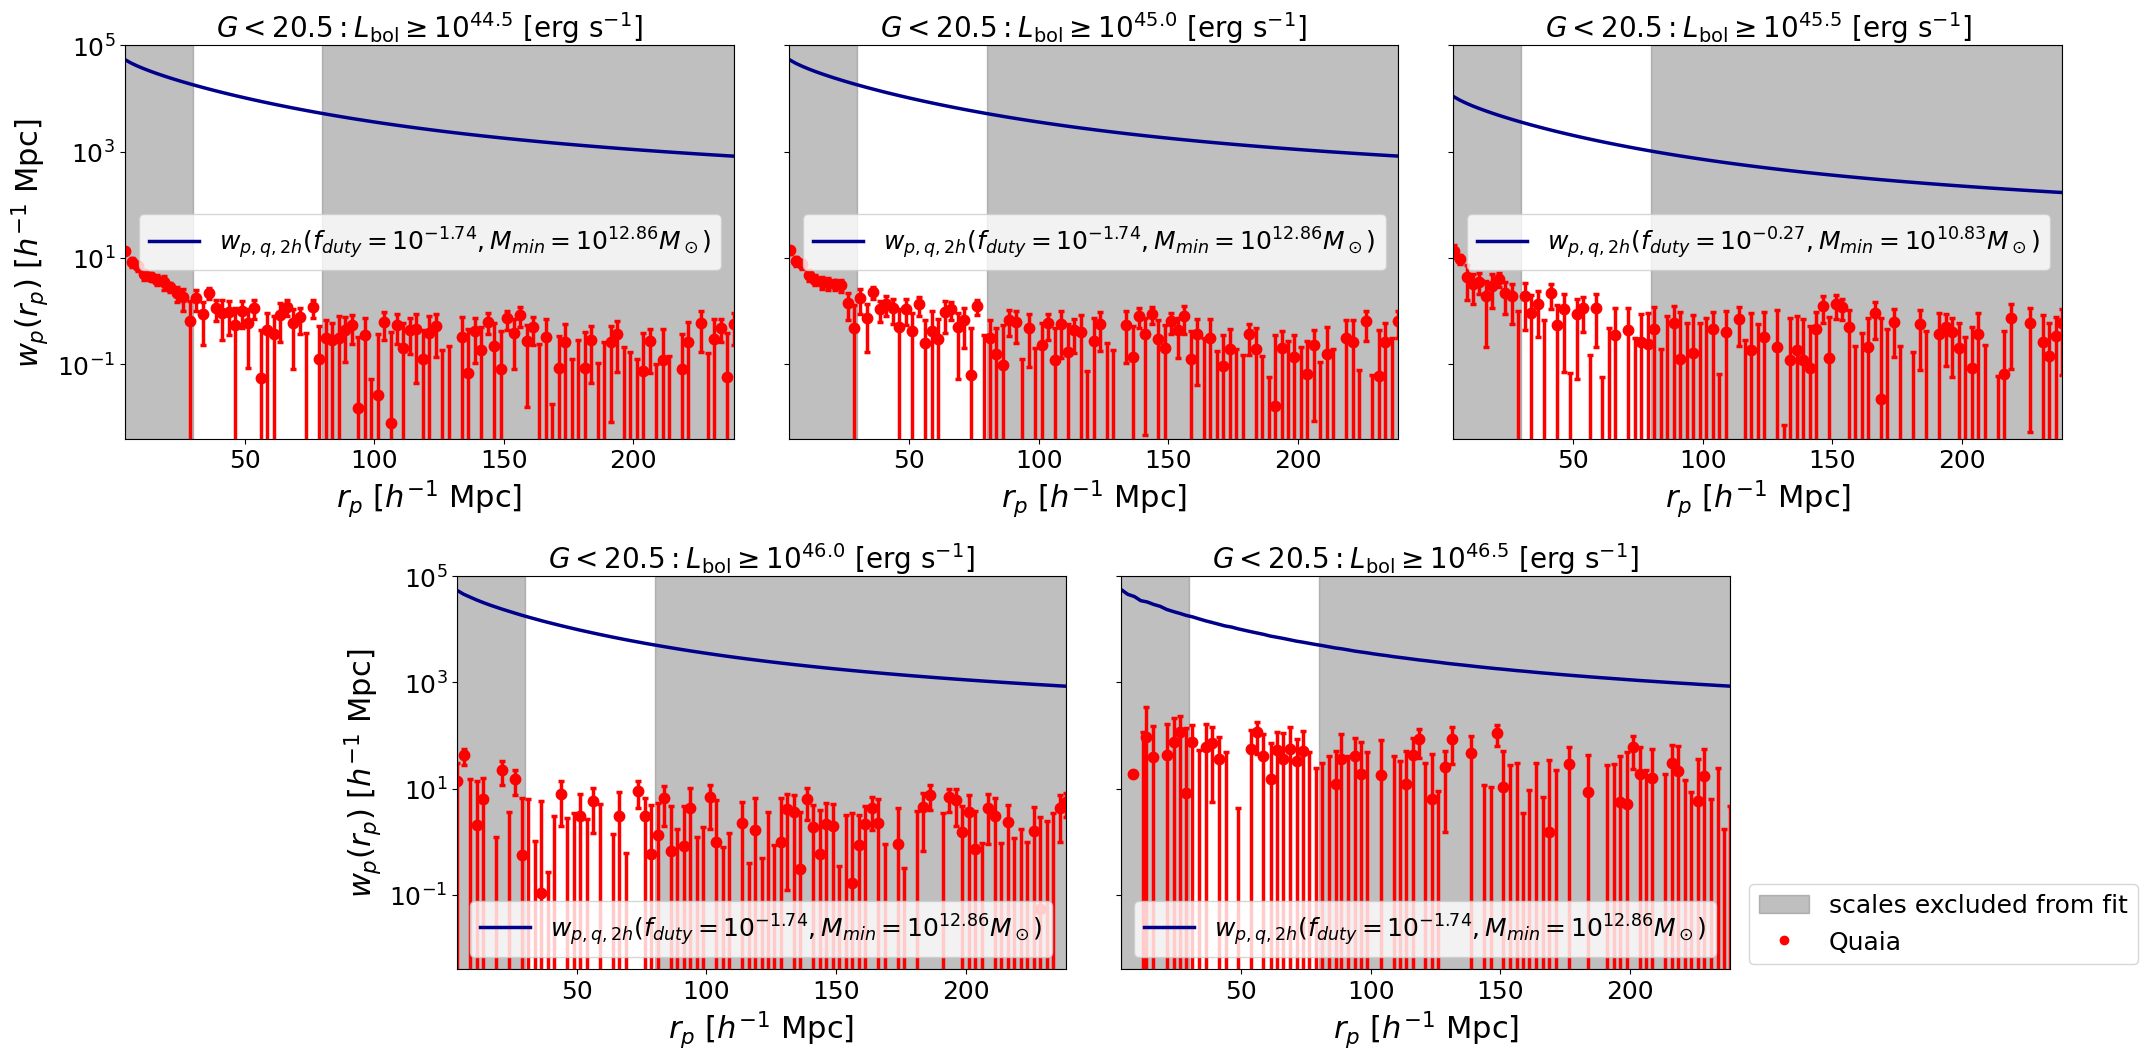

In [68]:
# plot!
fig = plt.figure(figsize = (25,12))  #27, 12
grid = gridspec.GridSpec(2, 6, hspace = 0.35) #0.25

ax1 = plt.subplot(grid[0, 0:2])
ax2 = plt.subplot(grid[0, 2:4])
ax3 = plt.subplot(grid[0, 4:6])
ax4 = plt.subplot(grid[1, 1:3])
ax5 = plt.subplot(grid[1, 3:5])
axlist = [ax1, ax2, ax3, ax4, ax5] #https://www.geeksforgeeks.org/matplotlib-gridspec-gridspec-class-in-python/

# ylim = 2e-6, 4
k = 0
for j in range(len(L_bol)):

    ax1 = axlist[j]
    
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z0.0_Lbolmin{:.1f}_N25_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, L_bol[j]))
            
    ax1.errorbar(rpavg_chi2[j], wp_chi2[j], linewidth = 2.5, marker = 'o', 
                 color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5)#, label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)

    # plot new fit
    n_m=np.ones(np.shape(bins))*fduty_fit[j]
    wp_2h_zbin, b_q = wp_2h(np.logspace(np.log10(M_min_fit[j]),M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins_chi2, pibins,
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), wp_2h_zbin, linewidth = 2.5,
             label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty_fit[j]), 
                                                                                                        np.log10(M_min_fit[j])), 
             color = 'darkblue')

    ax1.set_title('$G<{}: L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(G_hi, L_bol[j]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_ylim(ylim)
    
    if (j == 0) or (j == 3):
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')

    else:
        ax1.set_yticklabels([])

    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=2

    if j == 4:
        custom_lines = [mpatches.Patch(color='grey', alpha = 0.5),
                        Line2D([0], [0], color = 'red', linestyle = 'none', marker = 'o', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, ['scales excluded from fit', r'Quaia'], bbox_to_anchor = (1.35, 0.25), loc='upper center')
        fig.add_artist(second_legend)

    ax1.legend()

plt.show()

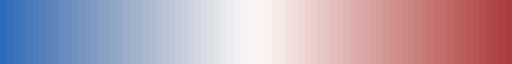

In [69]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:49: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:49: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_22240/2278790152.py:31: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
/tmp/ipykernel_22240/2278790152.py:43: SyntaxWarning: invalid escape sequence '\c'
  '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)',
/tmp/ipykernel_22240/2278790152.py:49: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


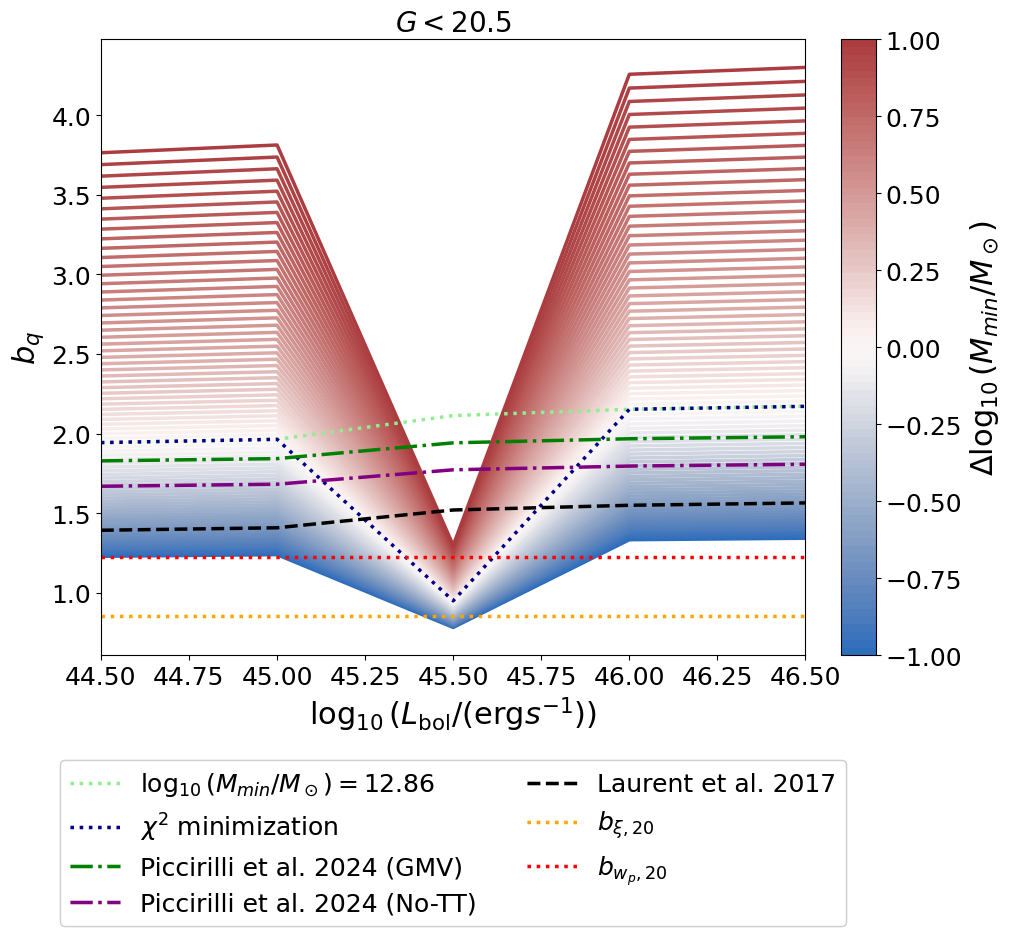

In [70]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
b_q = [wp_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, wp_chi2[j], rbins_chi2, pibins,
             recenter = False)[1] for j in range(len(L_bol))]
ax1.plot(L_bol, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [wp_2h(np.logspace(np.log10(M_min_fit[j]), M_max, 79), np.ones(np.shape(bins))*fduty_fit[j], a_zbin[j], cosmo_planck18, 
             wp_chi2[j], rbins_chi2, pibins, recenter = False)[1] for j in range(len(L_bol))]
ax1.plot(L_bol, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

for k in range(len(bins)):
    b_q = [wp_2h(np.logspace(np.log10(M_min_fit[j])-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*fduty_fit[j], a_zbin[j], 
                 cosmo_planck18, wp_chi2[j], rbins_chi2, pibins, recenter = False)[1] for j in range(len(L_bol))]
    ax1.plot(L_bol, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(L_bol, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(L_bol, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(L_bol, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.axhline(b_cf20[0], linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.axhline(b_wp20[0], linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
ax1.set_xlim(L_bol[0], L_bol[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 
                                          '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.15), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_22240/2443442664.py:26: SyntaxWarning: invalid escape sequence '\c'
  second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), '$\chi^2$ minimization',
/tmp/ipykernel_22240/2443442664.py:31: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')


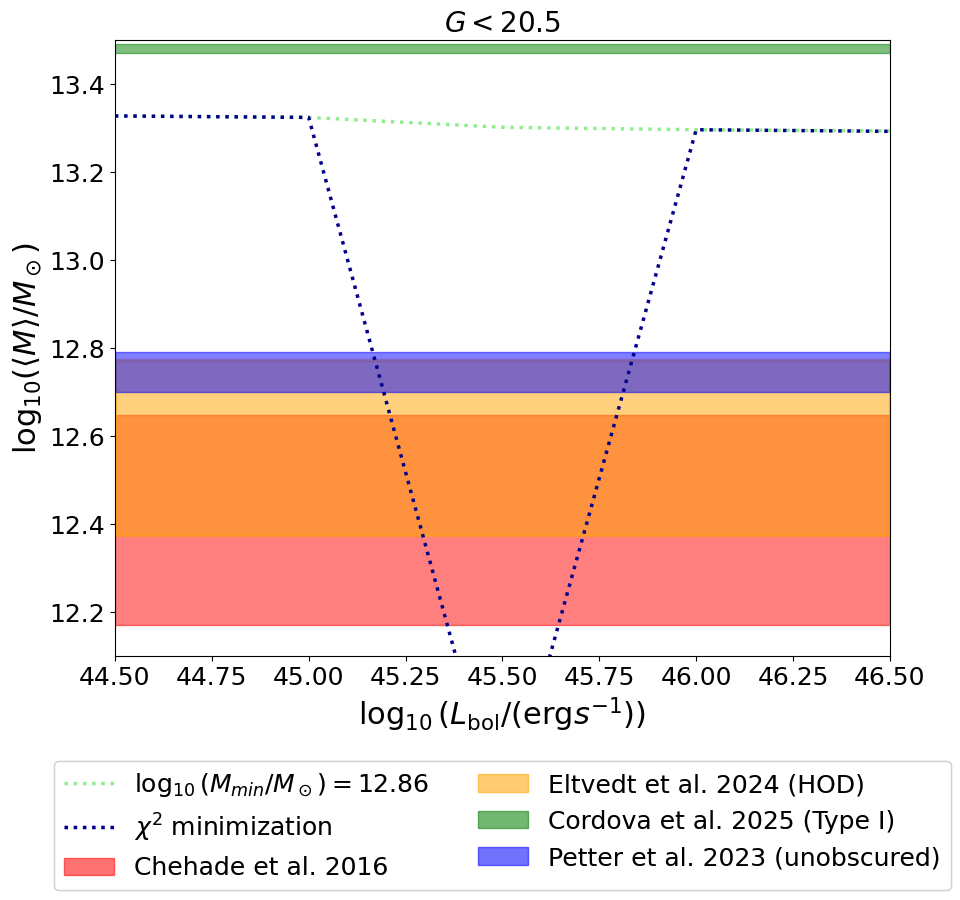

In [71]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in range(len(L_bol))]
ax1.plot(L_bol, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), np.ones(np.shape(bins))*fduty_fit[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in range(len(L_bol))]
ax1.plot(L_bol, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.fill_between(L_bol, [np.log10(1e12/cosmo_planck18['h'])]*len(L_bol), [np.log10(3e12/cosmo_planck18['h'])]*len(L_bol), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(L_bol, [np.log10(1.6e12/cosmo_planck18['h'])]*len(L_bol), [np.log10(4e12/cosmo_planck18['h'])]*len(L_bol), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(L_bol, [13.47]*len(L_bol), [13.49]*len(L_bol), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(L_bol, [np.log10(10**12.53/cosmo_planck18['h'])]*len(L_bol), [np.log10(10**12.62/cosmo_planck18['h'])]*len(L_bol), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), '$\chi^2$ minimization',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.15), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')

ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(L_bol[0], L_bol[-1])
ax1.set_ylim(12.1, 13.5)

plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\o'
<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_22240/559478700.py:34: SyntaxWarning: invalid escape sequence '\c'
  second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), '$\chi^2$ minimization',
/tmp/ipykernel_22240/559478700.py:39: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
/tmp/ipykernel_22240/559478700.py:45: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_22240/2313523635.py:30: RuntimeWarning: divi

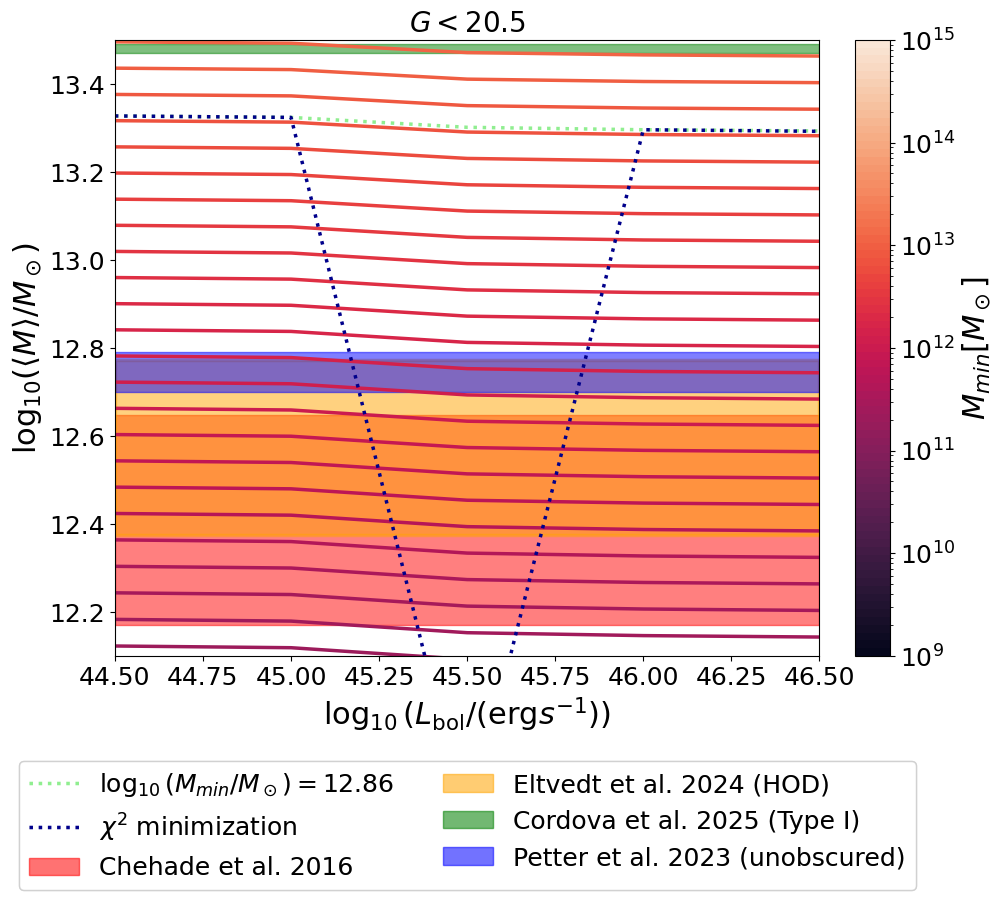

In [72]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    M_h = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in range(len(L_bol))]
    ax1.plot(L_bol, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap[k]) #, alpha = (1+k)/len(bins))
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in range(len(L_bol))]
ax1.plot(L_bol, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), np.ones(np.shape(bins))*fduty_fit[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in range(len(L_bol))]
ax1.plot(L_bol, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

# z = np.linspace(0.8, 2.25)
ax1.fill_between(L_bol, [np.log10(1e12/cosmo_planck18['h'])]*len(L_bol), [np.log10(3e12/cosmo_planck18['h'])]*len(L_bol), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(L_bol, [np.log10(1.6e12/cosmo_planck18['h'])]*len(L_bol), [np.log10(4e12/cosmo_planck18['h'])]*len(L_bol), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(L_bol, [13.47]*len(L_bol), [13.49]*len(L_bol), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(L_bol, [np.log10(10**12.53/cosmo_planck18['h'])]*len(L_bol), [np.log10(10**12.62/cosmo_planck18['h'])]*len(L_bol), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), '$\chi^2$ minimization',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.15), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')

ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(L_bol[0], L_bol[-1])
ax1.set_ylim(12.1, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\D'
<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_22240/434488228.py:33: SyntaxWarning: invalid escape sequence '\c'
  second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), '$\chi^2$ minimization',
/tmp/ipykernel_22240/434488228.py:38: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
/tmp/ipykernel_22240/434488228.py:44: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


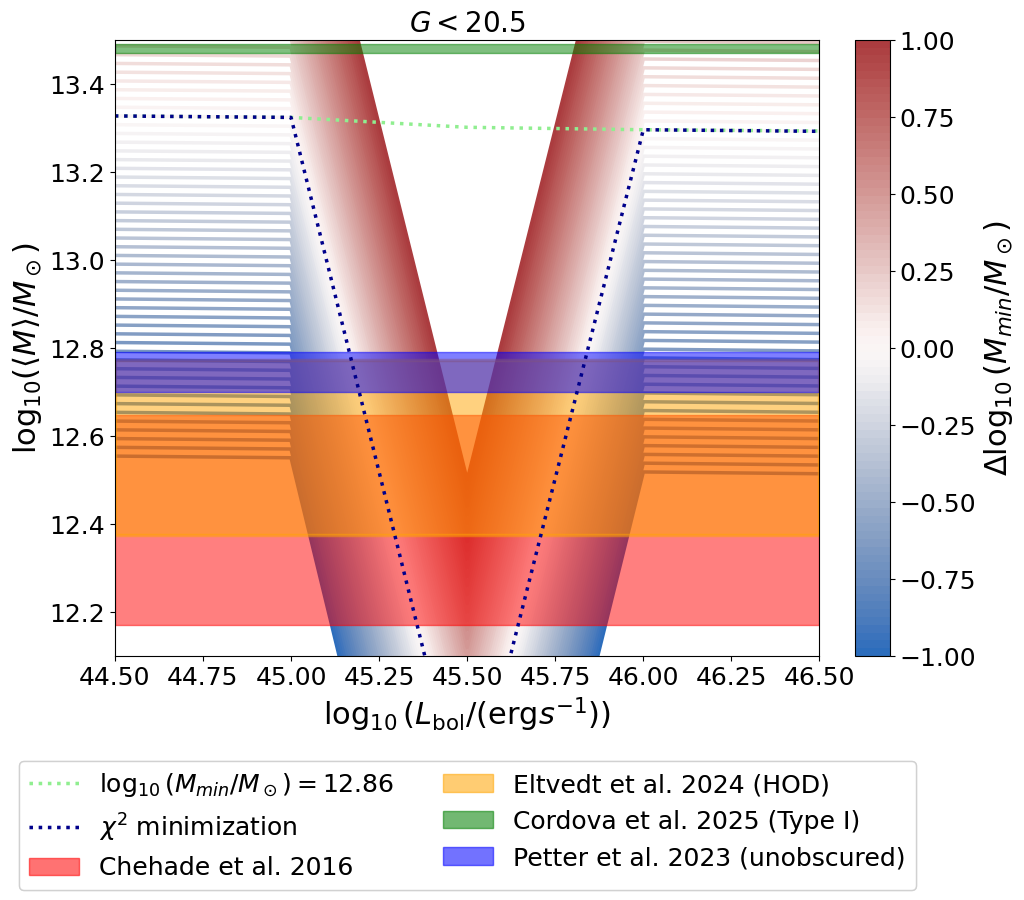

In [73]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    M_h = [M(np.logspace(np.log10(M_min_fit[j])-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*fduty_fit[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in range(len(L_bol))]
    ax1.plot(L_bol, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in range(len(L_bol))]
ax1.plot(L_bol, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), np.ones(np.shape(bins))*fduty_fit[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in range(len(L_bol))]
ax1.plot(L_bol, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.fill_between(L_bol, [np.log10(1e12/cosmo_planck18['h'])]*len(L_bol), [np.log10(3e12/cosmo_planck18['h'])]*len(L_bol), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(L_bol, [np.log10(1.6e12/cosmo_planck18['h'])]*len(L_bol), [np.log10(4e12/cosmo_planck18['h'])]*len(L_bol), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(L_bol, [13.47]*len(L_bol), [13.49]*len(L_bol), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(L_bol, [np.log10(10**12.53/cosmo_planck18['h'])]*len(L_bol), [np.log10(10**12.62/cosmo_planck18['h'])]*len(L_bol), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), '$\chi^2$ minimization',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.15), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(L_bol[0], L_bol[-1])
ax1.set_ylim(12.1, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\o'
<>:74: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\o'
<>:74: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_22240/153037300.py:32: SyntaxWarning: invalid escape sequence '\c'
  label = '$\chi^2$ minimization'),
/tmp/ipykernel_22240/153037300.py:37: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
/tmp/ipykernel_22240/153037300.py:42: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_22240/153037300.py:74: SyntaxWarning: inva

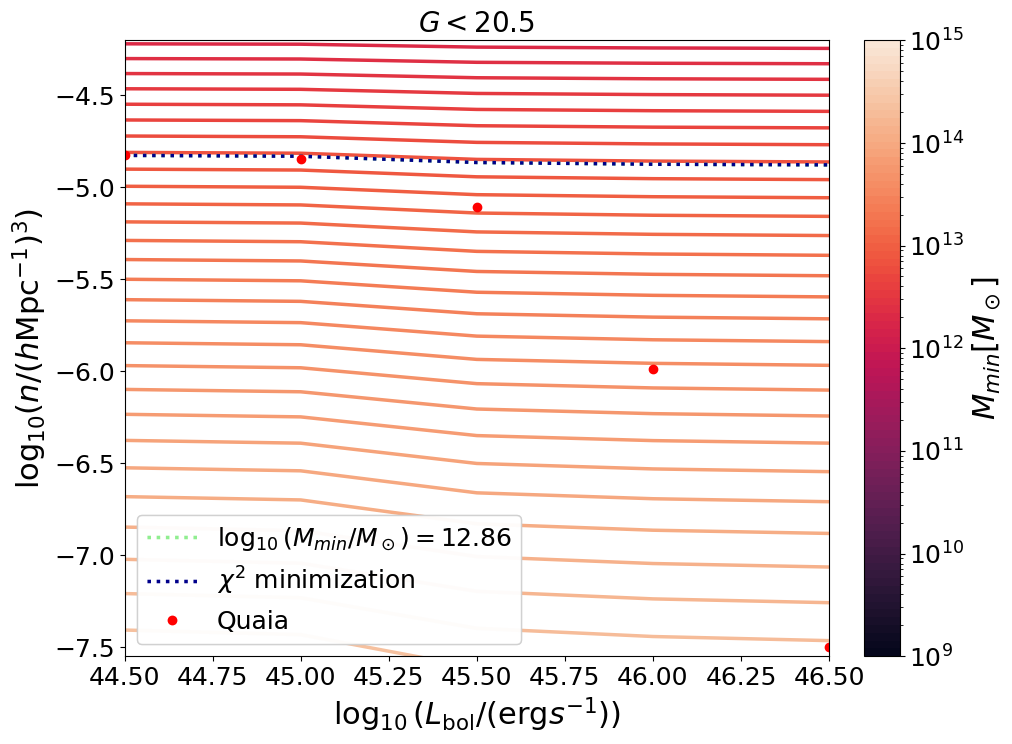

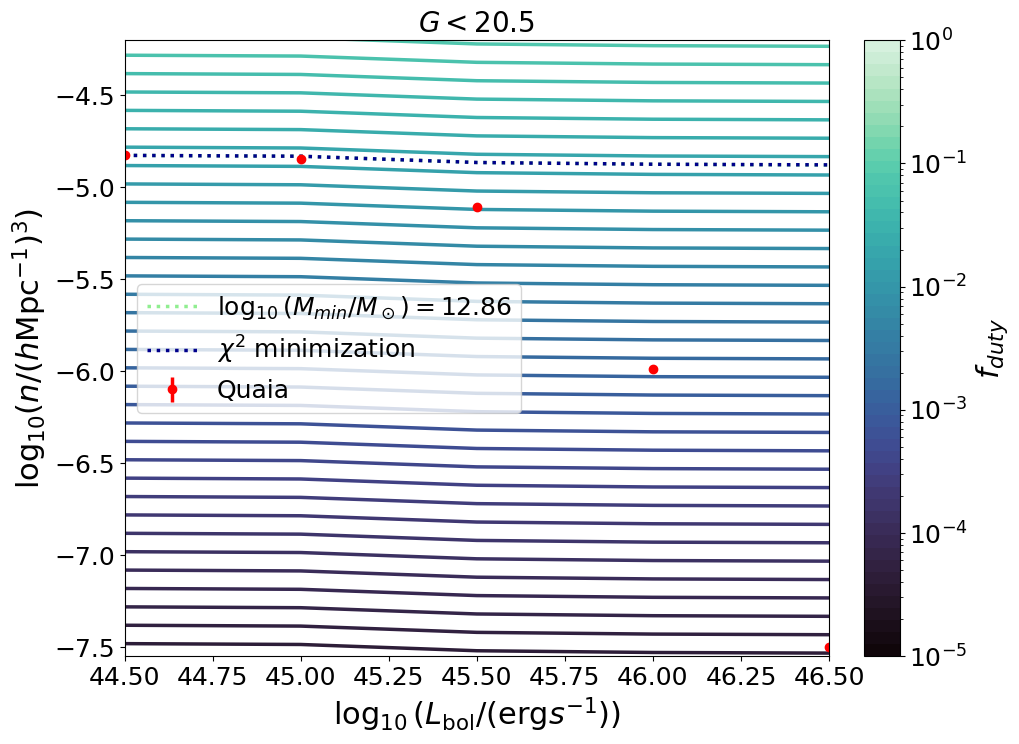

In [98]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
ylim = -7.55, -4.2

for k in range(len(bins)):
    
    n_q_theory = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in range(len(L_bol))]
    ax1.plot(L_bol, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap[k])

n_q_theory, n_q_theory_fit = [], []
for j in range(len(L_bol)):
    
    n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    
    n_m=np.ones(np.shape(bins))*fduty_fit[j]
    n_q_theory_fit.append(M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])

ax1.plot(L_bol, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.plot(L_bol, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.errorbar(L_bol, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$'.format(G_hi))

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = '$\chi^2$ minimization'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
ax1.set_xlim(L_bol[0], L_bol[-1])

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1
l = 38

for k in range(len(fduty_array)):

    n_q_theory=[]
    for j in range(len(L_bol)):
        
        n_m=np.ones(np.shape(bins))*fduty_array[k]
        n_q_theory.append(M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
        
    ax1.plot(L_bol, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in range(len(L_bol))]
ax1.plot(L_bol, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])

ax1.plot(L_bol, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(L_bol, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
ax1.legend()
ax1.set_xlim(L_bol[0], L_bol[-1])

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_fduty, norm = matplotlib.colors.LogNorm(vmin=fduty_array[0], vmax = fduty_array[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$f_{duty}$')
plt.show()

In [99]:
cmap_fduty_k = sns.color_palette("vlag", n_colors = len(fduty_array))

<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:75: SyntaxWarning: invalid escape sequence '\l'
<>:82: SyntaxWarning: invalid escape sequence '\D'
<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:75: SyntaxWarning: invalid escape sequence '\l'
<>:82: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_22240/3563557689.py:33: SyntaxWarning: invalid escape sequence '\c'
  label = '$\chi^2$ minimization'),
/tmp/ipykernel_22240/3563557689.py:38: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
/tmp/ipykernel_22240/3563557689.py:43: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
/tmp/ipykernel_22240/3563557689.py:75: SyntaxWarning: invalid escape sequence '\l'
  a

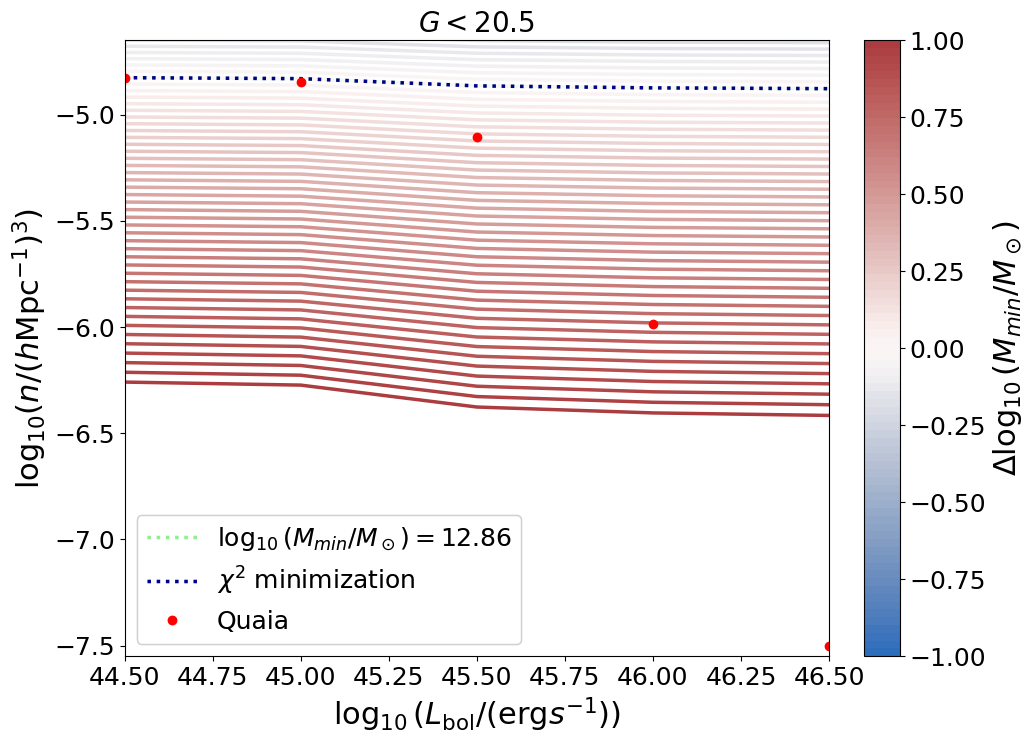

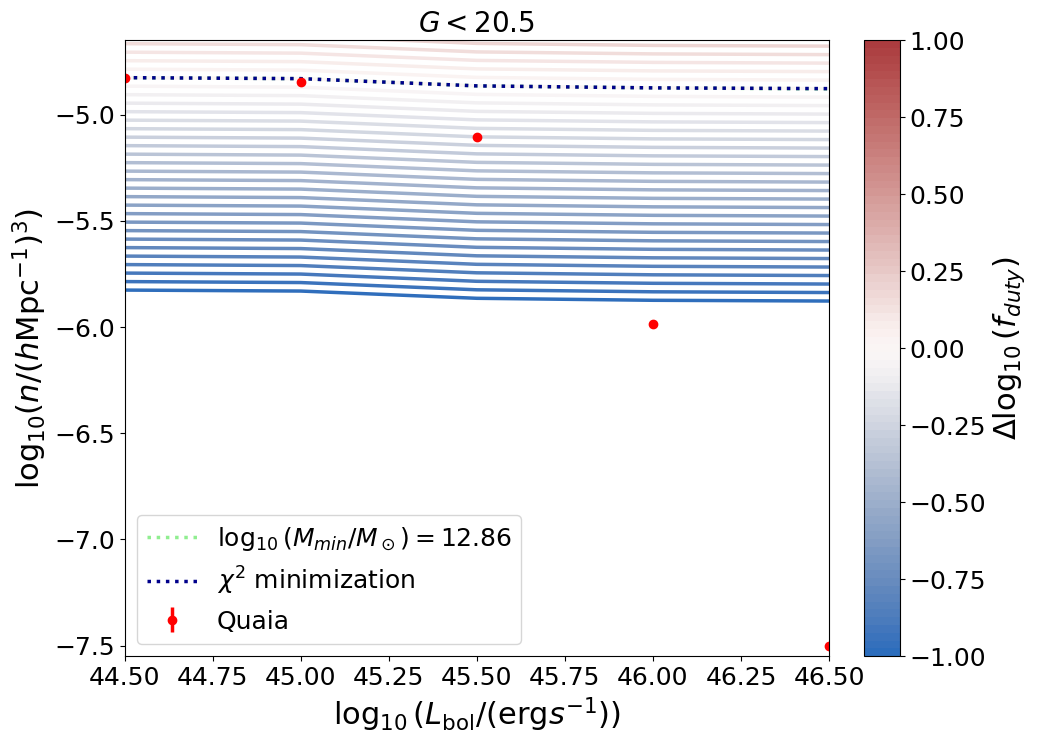

In [100]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
ylim = -7.55, -4.65

for k in range(len(bins)):
    
    n_q_theory = [M(np.logspace(np.log10(M_min_fit[j])-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*fduty_fit[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in range(len(L_bol))]
    ax1.plot(L_bol, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap_M_min[k])

n_q_theory, n_q_theory_fit = [], []
for j in range(len(L_bol)):
    
    n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    
    n_m=np.ones(np.shape(bins))*fduty_fit[j]
    n_q_theory_fit.append(M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])

ax1.plot(L_bol, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.plot(L_bol, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.errorbar(L_bol, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_xlim(L_bol[0], L_bol[-1])

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = '$\chi^2$ minimization'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1
l = 38

for k in range(len(fduty_array)):

    n_q_theory=[]
    for j in range(len(L_bol)):
        
        n_m = np.ones(np.shape(bins))*10**(np.log10(fduty_fit[j])-1+k/int(len(fduty_array)/2))
        n_q_theory.append(M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
        
    ax1.plot(L_bol, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty_k[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in range(len(L_bol))]
ax1.plot(L_bol, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])

ax1.plot(L_bol, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(L_bol, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
ax1.legend()
ax1.set_xlim(L_bol[0], L_bol[-1])

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(f_{duty})$')
plt.show()

# Plot the QLF

In [77]:
def phi(z, M):

    
    F_0 = np.polynomial.chebyshev.Chebyshev((-7.798, 1.128, -0.120))
    phi_star = 10**F_0(1+z)

    F_1 = np.polynomial.chebyshev.Chebyshev((-17.163, -5.512, 0.593, -0.024))
    M_star = F_1(1+z)

    F_2 = np.polynomial.chebyshev.Chebyshev((-3.223, -0.258))
    alpha = F_2(1+z)

    zeta = np.log10((1+z)/(1+3.773))
    beta = -2.312+0.559/(10**(141.884*zeta)+10**(-0.171*zeta))

    return phi_star/(10**(0.4*(alpha+1)*(M-M_star))+10**(0.4*(beta+1)*(M-M_star)))/u.Mpc**3/u.mag

 ## Convert bolometric luminosity to monochromatic luminosity at a rest frame of $1450\mathring{A}$

In [78]:
def L_lambda(L_bol, angstrom = 1450*u.angstrom):
    
    A = 4.74
    B = 0.91
    # angstrom = 1450*u.angstrom # Angstrom
    
    try:
        L_bol = L_bol.value
    except:
        pass
        
    return (L_bol/10**A)**(1/B)*u.erg/u.s/angstrom

## Convert monochromatic luminosity to absolute AB magnitude

In [79]:
def m_AB(L_bol, angstrom = 1450*u.angstrom):

    d = 10*u.pc
    # f_v = angstrom**2/const.c*L_lambda(tab_datahi_mask_zbin0['L_bol'], angstrom)/(4*np.pi*d**2)
    f_lambda = L_lambda(L_bol, angstrom = angstrom)/(4*np.pi*d**2)
    # f_v = f_lambda.to(u.erg/u.s/u.cm**2/u.Hz, u.spectral_density(angstrom))
    
    # return -2.5*np.log10(f_v/(3631*u.Jy))
    return f_lambda.to(u.ABmag, u.spectral_density(angstrom))

In [80]:
m_AB(tab_datahi_mask_zbin0['L_bol'])

<Magnitude [-27.03430165, -25.25641942, -25.42117004, ..., -24.9272143 ,
            -25.39313916, -26.87510024] mag(AB)>

## Integrate the QLF

In [81]:
z_array = np.linspace(0,1)

In [82]:
N_exp = []
for i in range(len(L_bol)):
    
    M_array = m_AB(np.logspace(L_bol[i], 49)).value[::-1]
    dz, dM = np.meshgrid(z_array, M_array)
    
    cp = np.percentile(selfunc_hi_bins[i], mask*100)
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[i][selfunc_hi_bins[i]>=cp]*hp.nside2pixarea(NSIDE))
    dV_dz = f_sky*Planck18.differential_comoving_volume(dz)*4*np.pi*u.sr #*cosmo_quaia['h']**3 # convert to 1/Mpc^3
    
    # phi_dM = np.trapz(phi(dz, dM)*V_eff[i].to(u.Mpc**3, cu.with_H0(H0)), z_array)
    phi_dM = np.trapz(phi(dz, dM)*dV_dz, z_array)
    N_exp.append(np.trapz(phi_dM, M_array)*u.mag)

In [83]:
zmax = quaia.comoving_dist(1, h = cosmo_planck18['h'], Om0 = cosmo_planck18['Omega_m']) #) cosmos[i]['Omega_m']+cosmos[i]['Omega_c']).value # Mpc/h
zmin = quaia.comoving_dist(0, h = cosmo_planck18['h'], Om0 = cosmo_planck18['Omega_m']) #cosmos[i]['Omega_b']+cosmos[i]['Omega_c']).value # Mpc/h
4/3*np.pi*(zmax**3-zmin**3)

<Quantity 5.04318477e+10 Mpc3 / littleh3>

In [84]:
Planck18.comoving_volume(1)*cosmo_planck18['h']**3/u.h**3

<Quantity 5.07980909e+10 Mpc3 / h3>

In [85]:
np.trapz(Planck18.differential_comoving_volume(z_array)*np.pi*4*u.sr*cosmo_planck18['h']**3/u.h**3, z_array)

<Quantity 5.08014823e+10 Mpc3 / h3>

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_22240/1261825789.py:7: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(L_bol, N_exp, linestyle = '--', label = '$L_\mathrm{bol}\geq L_\mathrm{bol,min}$')
/tmp/ipykernel_22240/1261825789.py:8: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$N_{\mathrm{QSO},0<z\leq1}$')
/tmp/ipykernel_22240/1261825789.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_xlabel('$\log_{10}(L_\mathrm{bol,min}/(\mathrm{erg }s^{-1}))$')
/tmp/ipykernel_22240/1261825789.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$N_\mathrm{Quaia}/N_\mathrm{exp}

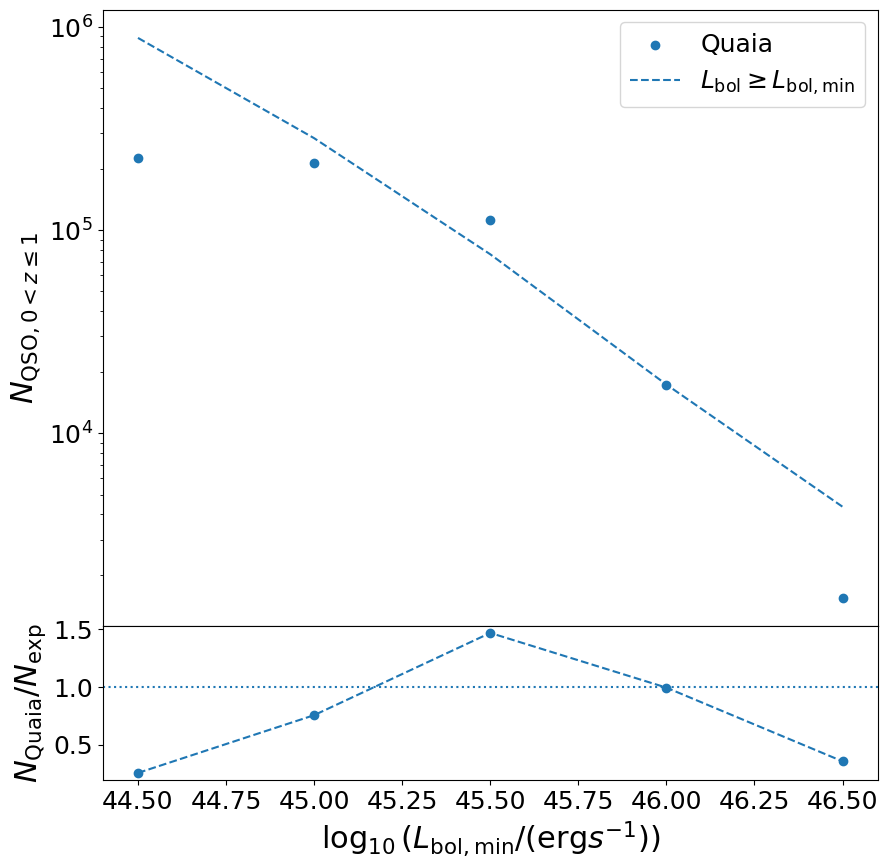

In [86]:
fig = plt.figure(figsize = (10, 10))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.25], hspace = 0)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1.scatter(L_bol, N_q, label = 'Quaia')
ax1.plot(L_bol, N_exp, linestyle = '--', label = '$L_\mathrm{bol}\geq L_\mathrm{bol,min}$')
ax1.set_ylabel('$N_{\mathrm{QSO},0<z\leq1}$')
ax1.set_yscale('log')
ax1.legend()

ax2.plot(L_bol,np.array(N_q)/N_exp, marker = 'o', linestyle = '--')
ax2.axhline(1, linestyle = ':')
ax2.set_xlabel('$\log_{10}(L_\mathrm{bol,min}/(\mathrm{erg }s^{-1}))$')
ax2.set_ylabel('$N_\mathrm{Quaia}/N_\mathrm{exp}$')
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_22240/3755423760.py:8: SyntaxWarning: invalid escape sequence '\m'
  ax1.scatter(zbin[i], N_exp[i], linestyle = '--', label = '$L_\mathrm{{bol}}\geq 10^{{{}}} \mathrm{{erg }}s^{{-1}}$'.format(L_bol[i]), color = cmap_blue[i], marker = 'P')
/tmp/ipykernel_22240/3755423760.py:11: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$N_{\mathrm{QSO},0<z\leq1}$')
/tmp/ipykernel_22240/3755423760.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$N_\ma

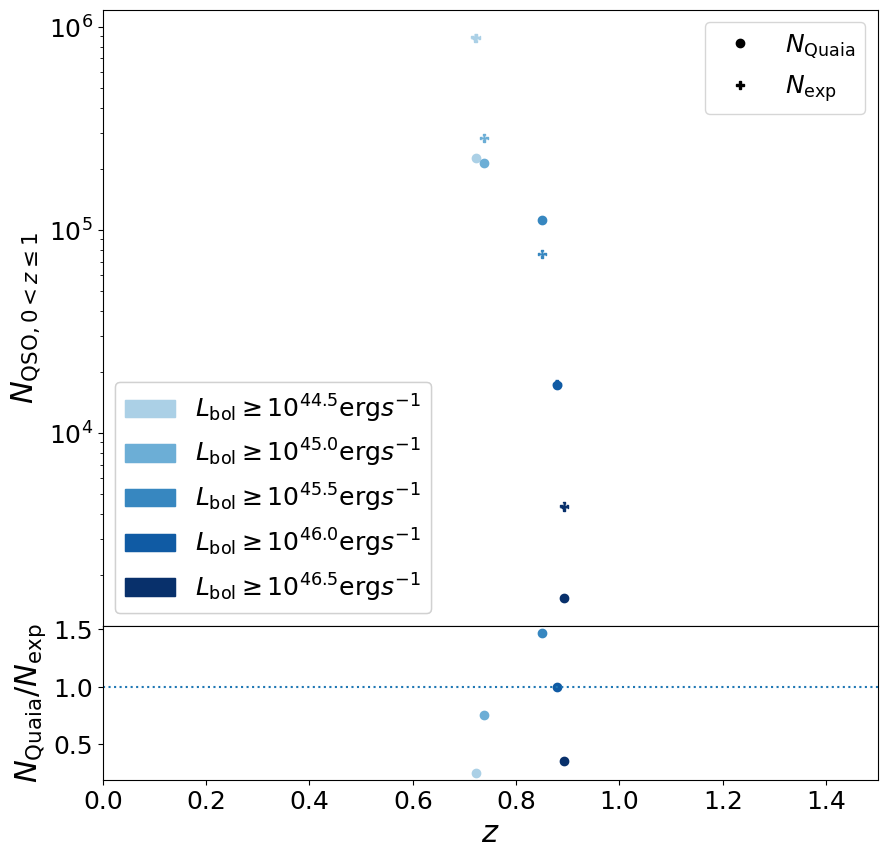

In [87]:
fig = plt.figure(figsize = (10, 10))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.25], hspace = 0)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

for i in range(len(L_bol)):
    ax1.scatter(zbin[i], N_q[i], label = 'Quaia', color = cmap_blue[i])
    ax1.scatter(zbin[i], N_exp[i], linestyle = '--', label = '$L_\mathrm{{bol}}\geq 10^{{{}}} \mathrm{{erg }}s^{{-1}}$'.format(L_bol[i]), color = cmap_blue[i], marker = 'P')
    ax2.plot(zbin[i],np.array(N_q)[i]/N_exp[i], color = cmap_blue[i], marker = 'o', linestyle = '--')

ax1.set_ylabel('$N_{\mathrm{QSO},0<z\leq1}$')
ax1.set_yscale('log')
ax1.set_xlim(0,1.5)
ax1.set_xticklabels([])
# ax1.legend()

ax2.axhline(1, linestyle = ':')
ax2.set_xlabel('$z$')
ax2.set_ylabel('$N_\mathrm{Quaia}/N_\mathrm{exp}$')
ax2.set_xlim(0,1.5)

custom_lines = [Line2D([0], [0], color = 'black', linestyle = 'none', marker = 'o'), Line2D([0], [0], color = 'black', linestyle = 'none', marker = 'P')]
second_legend = ax1.legend(custom_lines, [r'$N_\mathrm{Quaia}$', '$N_\mathrm{exp}$'])
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=color) for color in cmap_blue]
first_legend = ax1.legend(custom_lines, ['$L_\mathrm{{bol}}\geq 10^{{{}}} \mathrm{{erg }}s^{{-1}}$'.format(L) for L in L_bol], loc = 'lower left')
fig.add_artist(first_legend)

plt.show()

## Redo with updated $N_\mathrm{exp}$ constraint

In [88]:
error = [0.05, 0.05, 0.05, 0.05, 0.05]
res, M_min_fit, fduty_fit = [], [], []

chi2_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in range(len(L_bol))}
cons_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in range(len(L_bol))}
for j in range(len(L_bol)):
    
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z0.0_Lbolmin{:.1f}_N25_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, L_bol[j]))    
    
    ix_grid = np.ix_(rpmask[j], rpmask[j])
    fun = lambda x: f0_GLS_solve(x, a_zbin[j], wp_matter_chi2[j], C[ix_grid], wp_chi2[j], rbins_chi2, pibins, rpmask = rpmask[j])
    if j > 2:
        correction = 1
    else:
        # correction = np.min((N_q[j]/N_exp[j], 1))
        correction = (N_q[j]/N_exp[j]).value
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[j], n_q[j]/correction, error = error[j])}) 
    result = minimize(fun, [fduty[0], M_min_array[0]], bounds = ((0,1), (9, 15)), constraints = cons)
        
    print('L>={} erg/s'.format(L_bol[j]))
    x = result.x[0], result.x[-1]
    
    chi2 = f0_GLS_solve(x, a_zbin[j], wp_matter_chi2[j], C[ix_grid], wp_chi2[j], rbins_chi2, pibins, rpmask = rpmask[j])
    df = nbins-len(x)
    
    print('           chi^2: {:.2f}'.format(chi2))
    print('   reduced chi^2: {:.2f}'.format(chi2/df))
    print('         delta n: {:.2e}'.format(constraint(x, a_zbin[j], n_q[j]/correction, error = error[j])))
    try:
        print('condition number: {:.2f}'.format(np.linalg.cond(C)))
    except:
        print('condition number: SVD did not converge')
    print('             PTE: {:.2e}\n'.format(stats.chi2.sf(chi2, df)))
    
    M_min_fit.append(10**result.x[-1])
    fduty_fit.append(result.x[0])
    res.append(result)
    
    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
            
            x = fduty_array[k], np.log10(bins[l])

            chi2_m = f0_GLS_solve(x, a_zbin[j], wp_matter_chi2[j], C[ix_grid], wp_chi2[j], rbins_chi2, pibins, rpmask = rpmask[j])
            chi2_grid[j][l,k]=chi2_m
            cons = constraint(x, a_zbin[j], n_q[j]/correction, error = error[j])
            cons_grid[j][l,k]=cons
    
np.log10(M_min_fit), np.log10(fduty_fit), res

L>=44.5 erg/s
           chi^2: 38762858825.87
   reduced chi^2: 416804933.61
         delta n: -6.95e-01
condition number: 17327490005125437440.00
             PTE: 0.00e+00



/tmp/ipykernel_22240/2313523635.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_22240/2313523635.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


L>=45.0 erg/s
           chi^2: 25381611749.64
   reduced chi^2: 272920556.45
         delta n: -1.68e-01
condition number: 4115194711448820224.00
             PTE: 0.00e+00

L>=45.5 erg/s
           chi^2: 19351413395.43
   reduced chi^2: 208079713.93
         delta n: -1.50e+00
condition number: 4433793589152132096.00
             PTE: 0.00e+00

L>=46.0 erg/s
           chi^2: 169043595.62
   reduced chi^2: 1817673.07
         delta n: -1.19e+01
condition number: 37359849412186112000.00
             PTE: 0.00e+00

L>=46.5 erg/s
           chi^2: 2568894.43
   reduced chi^2: 27622.52
         delta n: -4.20e+02
condition number: SVD did not converge
             PTE: 0.00e+00



(array([12.86      , 12.86      , 12.86      , 12.86      , 12.85885637]),
 array([-1.74472749, -1.74472749, -1.74472749, -1.74472749, -1.74484591]),
 [ message: Inequality constraints incompatible
   success: False
    status: 4
       fun: 38762858825.87096
         x: [ 1.800e-02  1.286e+01]
       nit: 1
       jac: [ 1.024e+03  8.547e+10]
      nfev: 3
      njev: 1,
   message: Inequality constraints incompatible
   success: False
    status: 4
       fun: 25381611749.64213
         x: [ 1.800e-02  1.286e+01]
       nit: 1
       jac: [-5.120e+02  5.619e+10]
      nfev: 3
      njev: 1,
   message: Inequality constraints incompatible
   success: False
    status: 4
       fun: 19351413395.431988
         x: [ 1.800e-02  1.286e+01]
       nit: 1
       jac: [-2.048e+03  4.397e+10]
      nfev: 3
      njev: 1,
   message: Inequality constraints incompatible
   success: False
    status: 4
       fun: 169043595.61748004
         x: [ 1.800e-02  1.286e+01]
       nit: 1
       jac: [

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_22240/676983591.py:8: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[j]))
/tmp/ipykernel_22240/676983591.py:10: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel('$\log_{

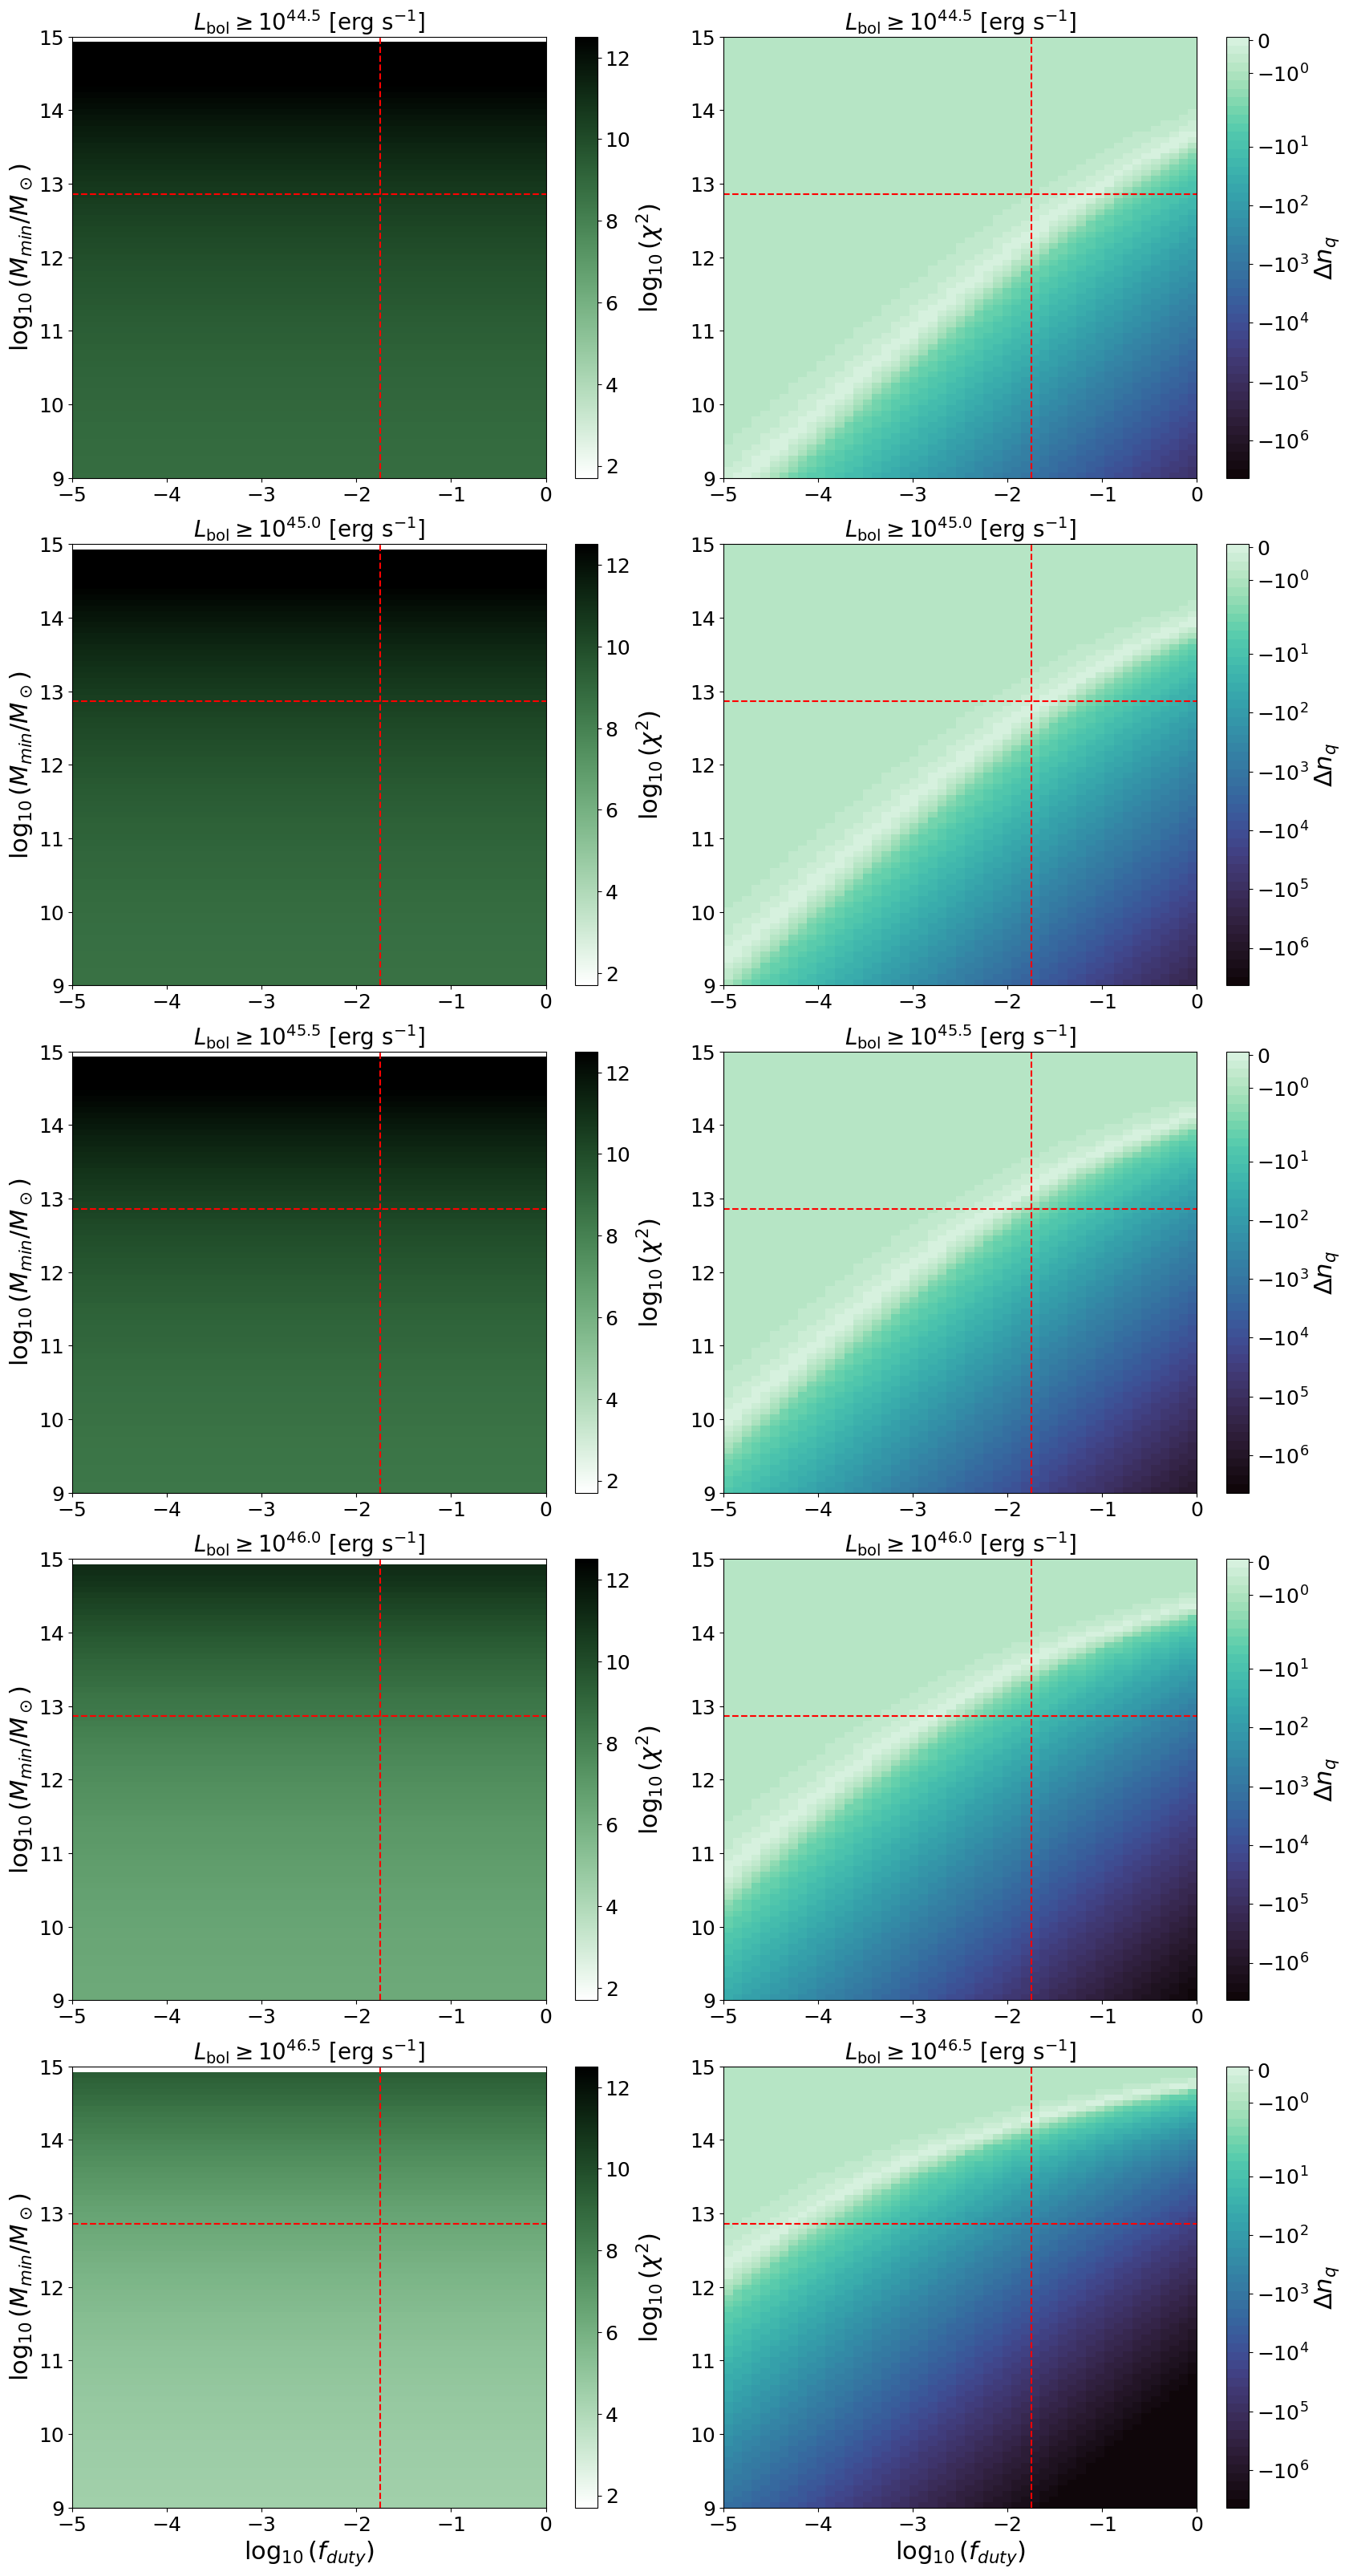

In [89]:
fig = plt.figure(figsize = (20, 40))
gs = gridspec.GridSpec(5, 2, hspace = 0.15, wspace = 0.1)

for j in range(len(L_bol)):
    
    ax1 = fig.add_subplot(gs[j*2])
    image = ax1.imshow(np.log10(chi2_grid[j]), cmap = cmap_chi2, vmin = np.log10(50.13706414974333), vmax = np.log10(3216118165719.2197), extent =  [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    ax1.set_title('$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[j]))
    if j == 4:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    ax1.set_ylabel('$\log_{10} (M_{min}/M_\odot)$')
    fig.colorbar(image, label='$\log_{10} (\chi^2)$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')
    
    ax1 = fig.add_subplot(gs[j*2+1])
    image = ax1.imshow(cons_grid[j], cmap = palette_fduty, norm = 'symlog', vmin = -4348491.828200184, vmax = 0.09959201649593023, extent = [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    ax1.set_title('$L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(L_bol[j]))
    if j == 4:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    fig.colorbar(image, label='$\Delta n_q$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')

plt.show()

## Plot results

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_22240/3432766316.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
/tmp/ipykernel_22240/3432766316.py:4: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')


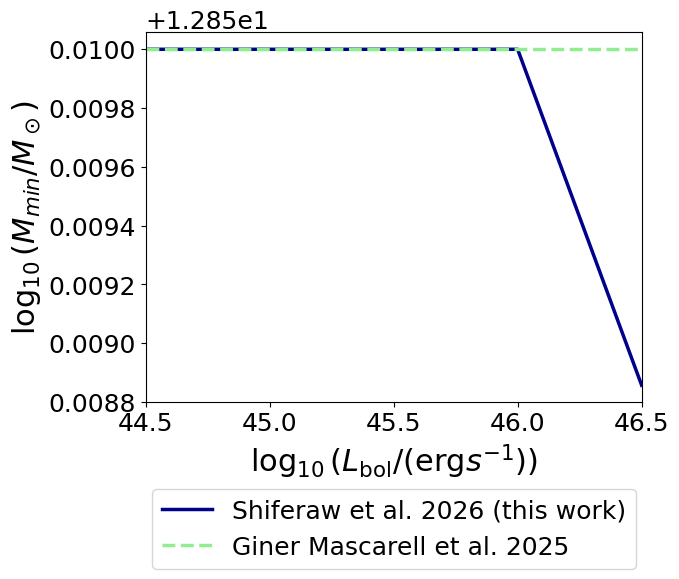

In [90]:
plt.plot(L_bol, np.log10(M_min_fit), color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.axhline(M_min_array[0], label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(L_bol[0], L_bol[-1])
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_22240/1055270469.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(f_{duty})$')
/tmp/ipykernel_22240/1055270469.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')


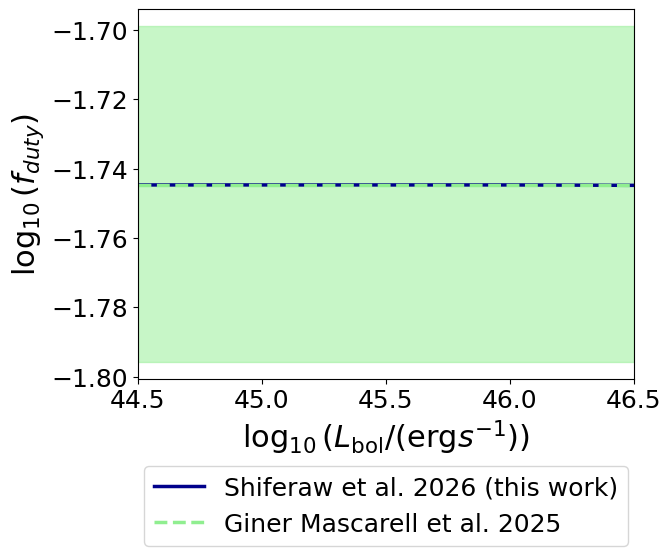

In [91]:
plt.plot(L_bol, np.log10(fduty_fit), color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(L_bol, [np.log10(fduty[0]+fduty_err_hi[0])]*len(L_bol), [np.log10(fduty[0]-fduty_err_lo[0])]*len(L_bol), alpha = 0.5, 
                 color = 'lightgreen')
plt.axhline(np.log10(fduty[0]), label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(L_bol[0], L_bol[-1])
plt.show()

<>:63: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_22240/3505452058.py:63: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('$G<{}: L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(G_hi, L_bol[j]))


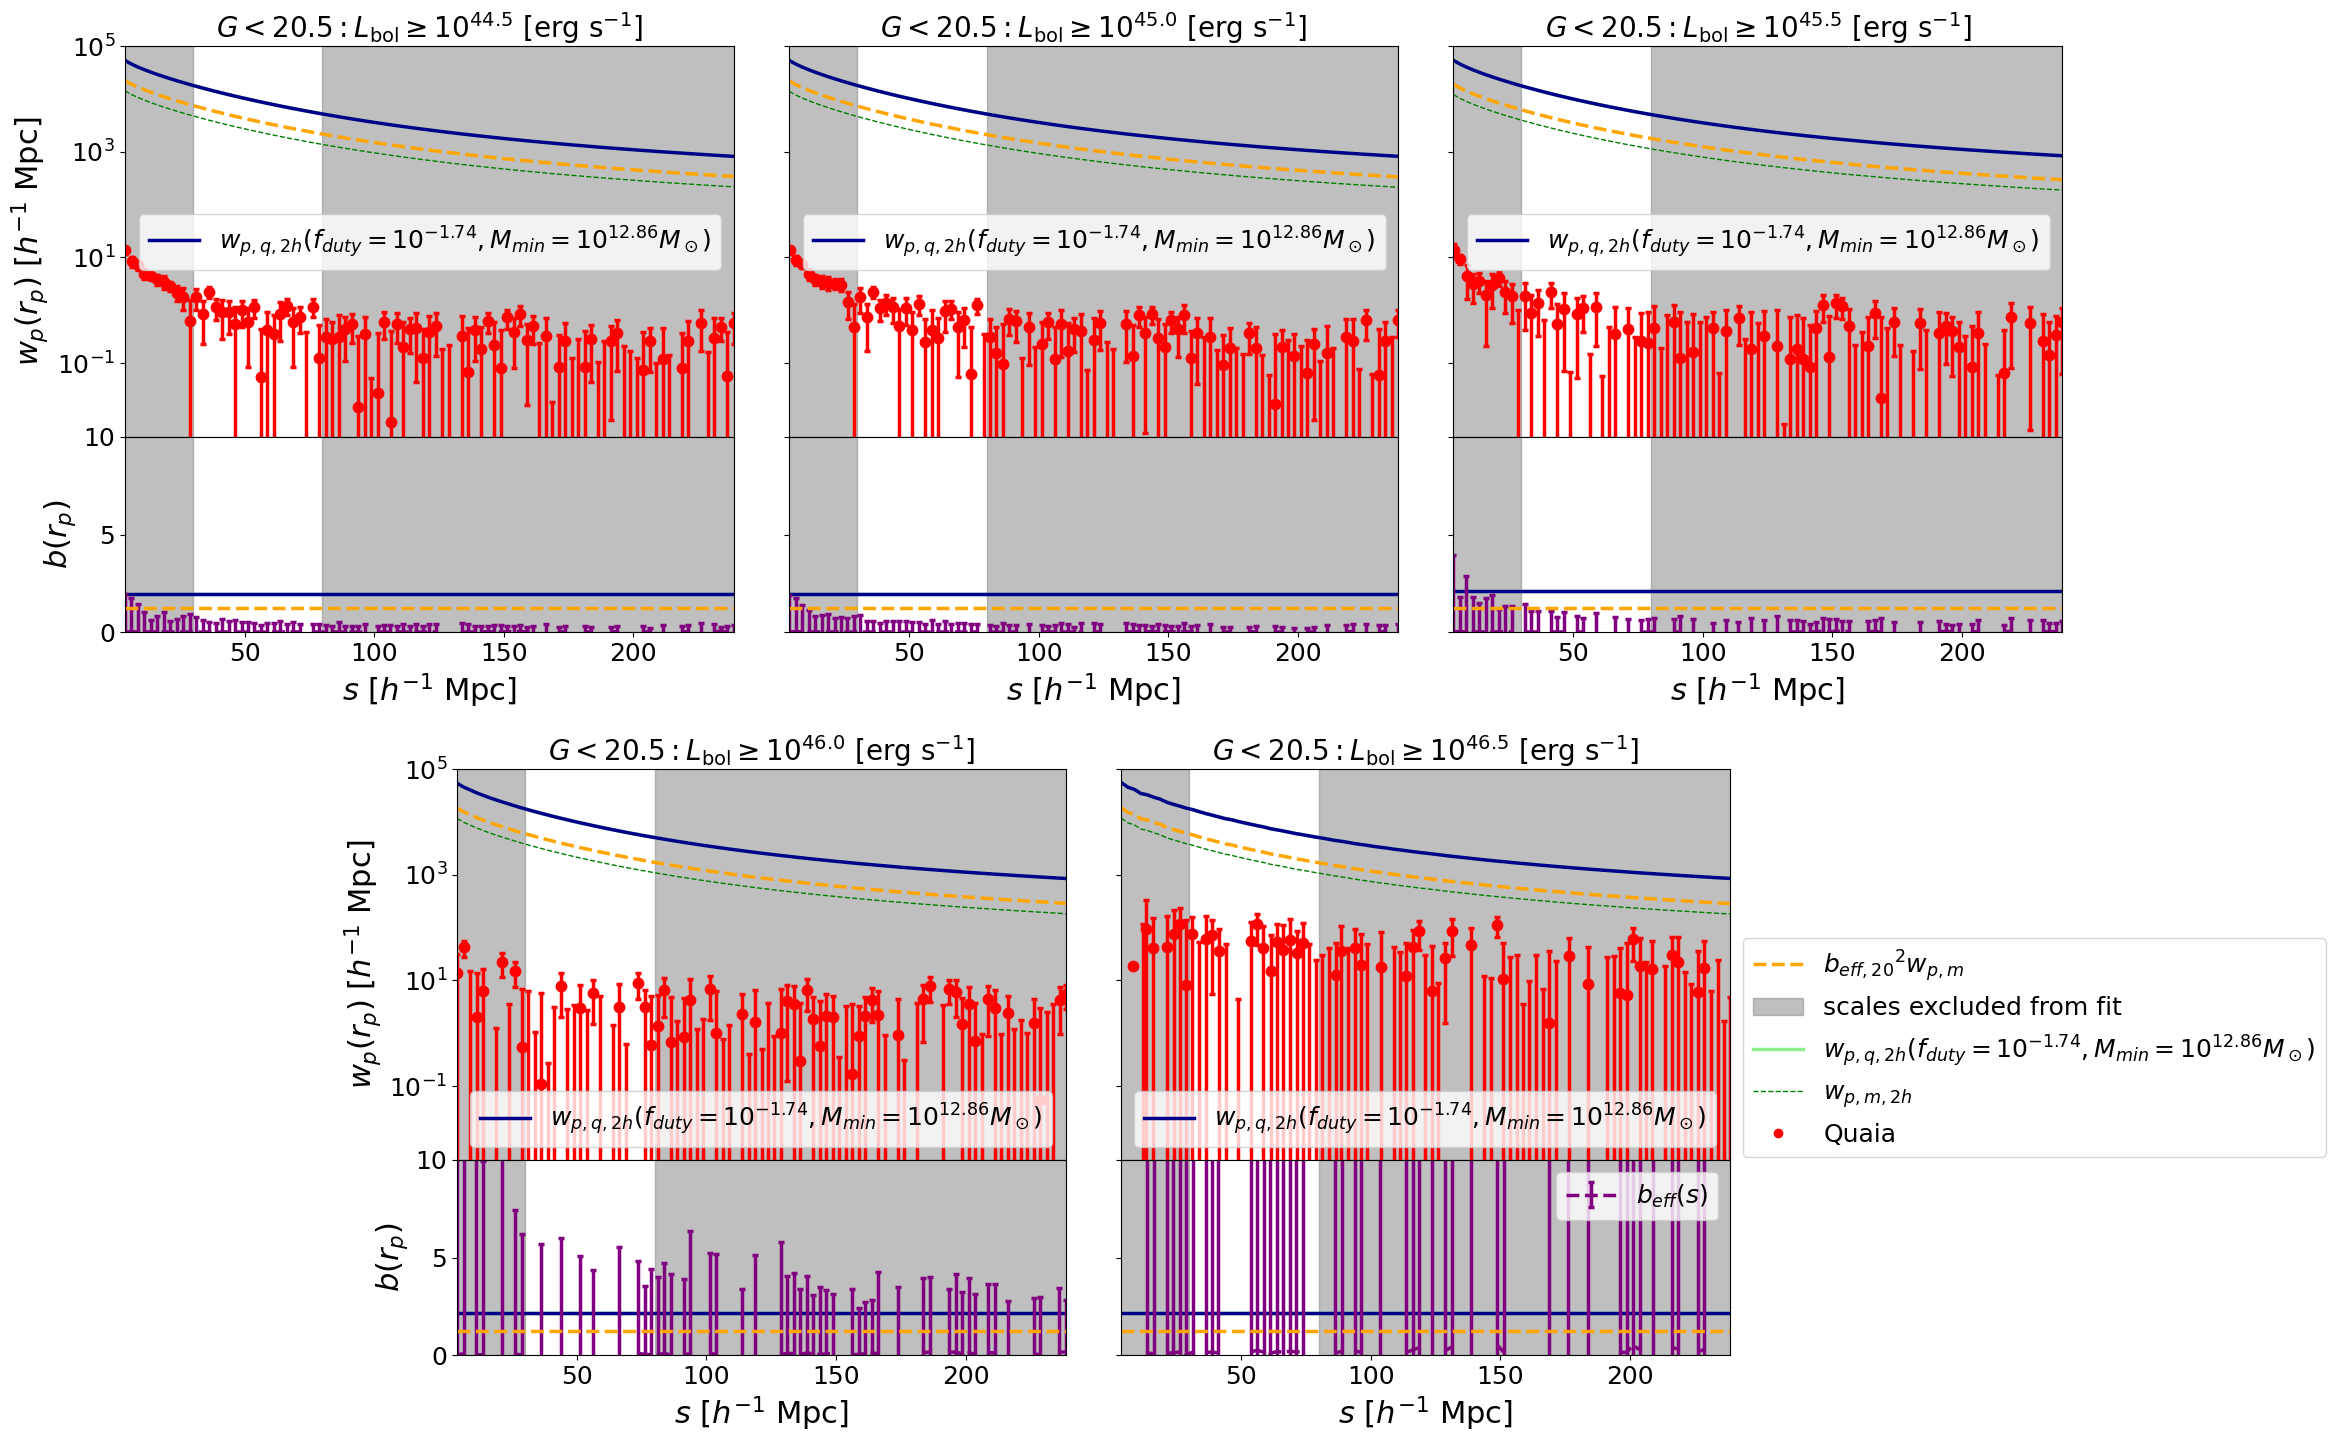

In [92]:
# plot!
fig = plt.figure(figsize = (25,17))  #13.5
grid = gridspec.GridSpec(5, 6, height_ratios = [1, 0.5, 0.35, 1, 0.5], hspace = 0) #0.25

ax1 = plt.subplot(grid[0, 0:2])
ax2 = plt.subplot(grid[0, 2:4])
ax3 = plt.subplot(grid[0, 4:6])
ax4 = plt.subplot(grid[3, 1:3])
ax5 = plt.subplot(grid[3, 3:5])
axlist = [ax1, ax2, ax3, ax4, ax5] #https://www.geeksforgeeks.org/matplotlib-gridspec-gridspec-class-in-python/

ax6 = plt.subplot(grid[1, 0:2])
ax7 = plt.subplot(grid[1, 2:4])
ax8 = plt.subplot(grid[1, 4:6])
ax9 = plt.subplot(grid[4, 1:3])
ax10 = plt.subplot(grid[4, 3:5])
axlist2 = [ax6, ax7, ax8, ax9, ax10] #https://www.geeksforgeeks.org/matplotlib-gridspec-gridspec-class-in-python/

ylim = 4e-3, 1e5
k = 0
for j in range(len(L_bol)):

    ax1 = axlist[j]
    ax2 = axlist2[j]
    
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z0.0_Lbolmin{:.1f}_N25_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, L_bol[j]))
            
    ax1.errorbar(rpavg_chi2[j], wp_chi2[j], linewidth = 2.5, marker = 'o', 
                 color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins_chi2), b_eff_wp20[0]**2*wp_matter_chi2[j], linewidth = 2.5,
             color = 'orange', linestyle = '--')
    ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5) # label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)

    # old fit
    wp_2h_zbin, b_q = wp_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins_chi2, pibins, recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), wp_2h_zbin, linewidth = 2.5, 
             color = 'lightgreen')
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*fduty_fit[j]
    wp_2h_zbin, b_q = wp_2h(np.logspace(np.log10(M_min_fit[j]),M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins_chi2, pibins,
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), wp_2h_zbin, linewidth = 2.5,
             label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty_fit[j]), 
                                                                                                        np.log10(M_min_fit[j])), 
             color = 'darkblue')
    ax1.plot(quaia.recenter(rbins_chi2), wp_matter_chi2[j], linewidth = 1, linestyle = '--', color = 'green')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')

    ax2.errorbar(quaia.recenter(rbins_chi2), b_wp_chi2[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    ax2.axhline(b_eff_wp20[0], linewidth = 2.5, color = 'orange', linestyle = '--')
    ax2.fill_betweenx(np.linspace(0, 10), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5)
    ax2.fill_betweenx(np.linspace(0, 10), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)
    
    ax1.set_title('$G<{}: L_\mathrm{{bol}}\geq10^{{{:.1f}}}$ [erg $\mathrm{{s}}^{{-1}}]$'.format(G_hi, L_bol[j]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(ylim)
    ax1.legend()

    ax2.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax2.set_ylim(0, 10)
    
    if (j == 0) or (j == 3):
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=4

custom_lines = [Line2D([0], [0], color = 'orange', linestyle = '--', linewidth = 2.5),
                mpatches.Patch(color='grey', alpha = 0.5),
                Line2D([0], [0], color = 'lightgreen', linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '--', linewidth = 1), 
                Line2D([0], [0], color = 'red', linestyle = 'none', marker = 'o', linewidth = 2.5)]
second_legend = ax2.legend(custom_lines, [r'${b_{eff, 20}}^2w_{p,m}$', 'scales excluded from fit', 
                                          r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[0]), 
                                                                                                                             M_min_array[0]), r'$w_{{p,m,2h}}$',
                                          r'Quaia'], bbox_to_anchor = (1.5, 2.2), loc='upper center')
fig.add_artist(second_legend)

ax2.legend()

plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:49: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:49: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_22240/2278790152.py:31: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
/tmp/ipykernel_22240/2278790152.py:43: SyntaxWarning: invalid escape sequence '\c'
  '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)',
/tmp/ipykernel_22240/2278790152.py:49: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


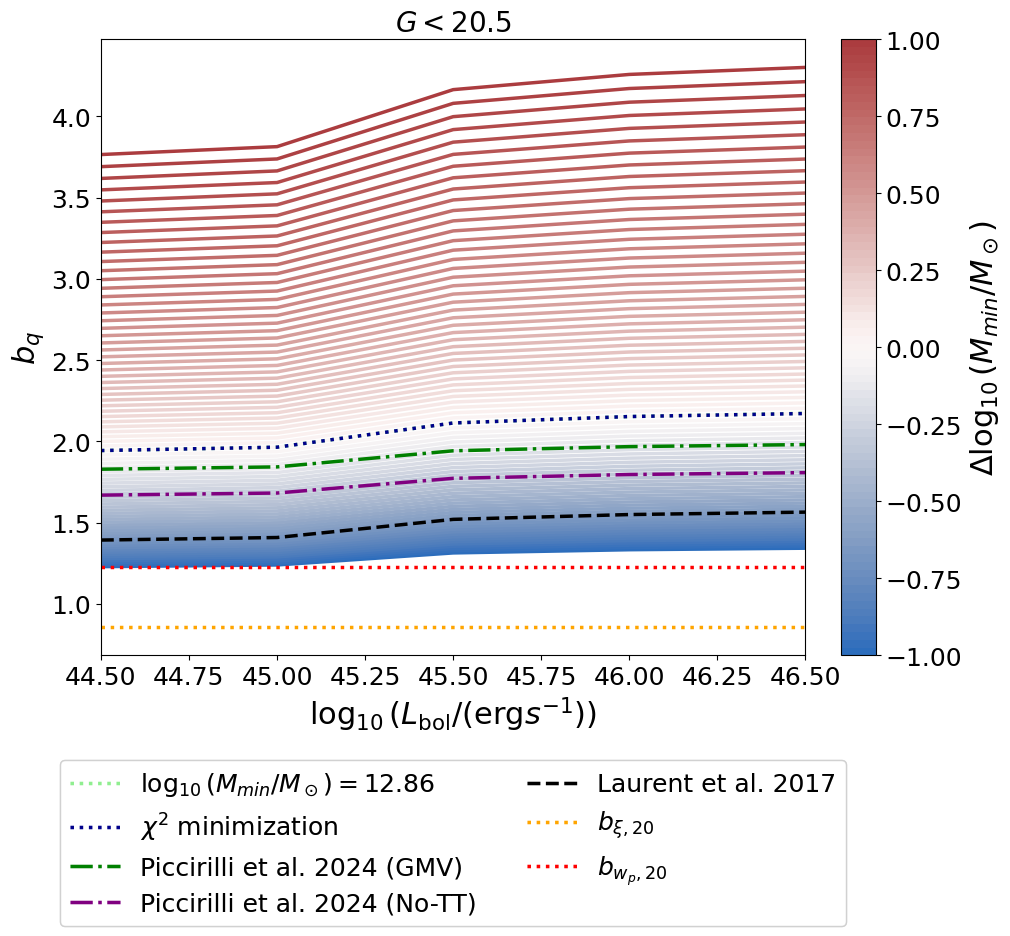

In [93]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
b_q = [wp_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, wp_chi2[j], rbins_chi2, pibins,
             recenter = False)[1] for j in range(len(L_bol))]
ax1.plot(L_bol, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [wp_2h(np.logspace(np.log10(M_min_fit[j]), M_max, 79), np.ones(np.shape(bins))*fduty_fit[j], a_zbin[j], cosmo_planck18, 
             wp_chi2[j], rbins_chi2, pibins, recenter = False)[1] for j in range(len(L_bol))]
ax1.plot(L_bol, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

for k in range(len(bins)):
    b_q = [wp_2h(np.logspace(np.log10(M_min_fit[j])-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*fduty_fit[j], a_zbin[j], 
                 cosmo_planck18, wp_chi2[j], rbins_chi2, pibins, recenter = False)[1] for j in range(len(L_bol))]
    ax1.plot(L_bol, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(L_bol, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(L_bol, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(L_bol, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.axhline(b_cf20[0], linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.axhline(b_wp20[0], linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
ax1.set_xlim(L_bol[0], L_bol[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 
                                          '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.15), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\D'
<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_22240/434488228.py:33: SyntaxWarning: invalid escape sequence '\c'
  second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), '$\chi^2$ minimization',
/tmp/ipykernel_22240/434488228.py:38: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
/tmp/ipykernel_22240/434488228.py:44: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


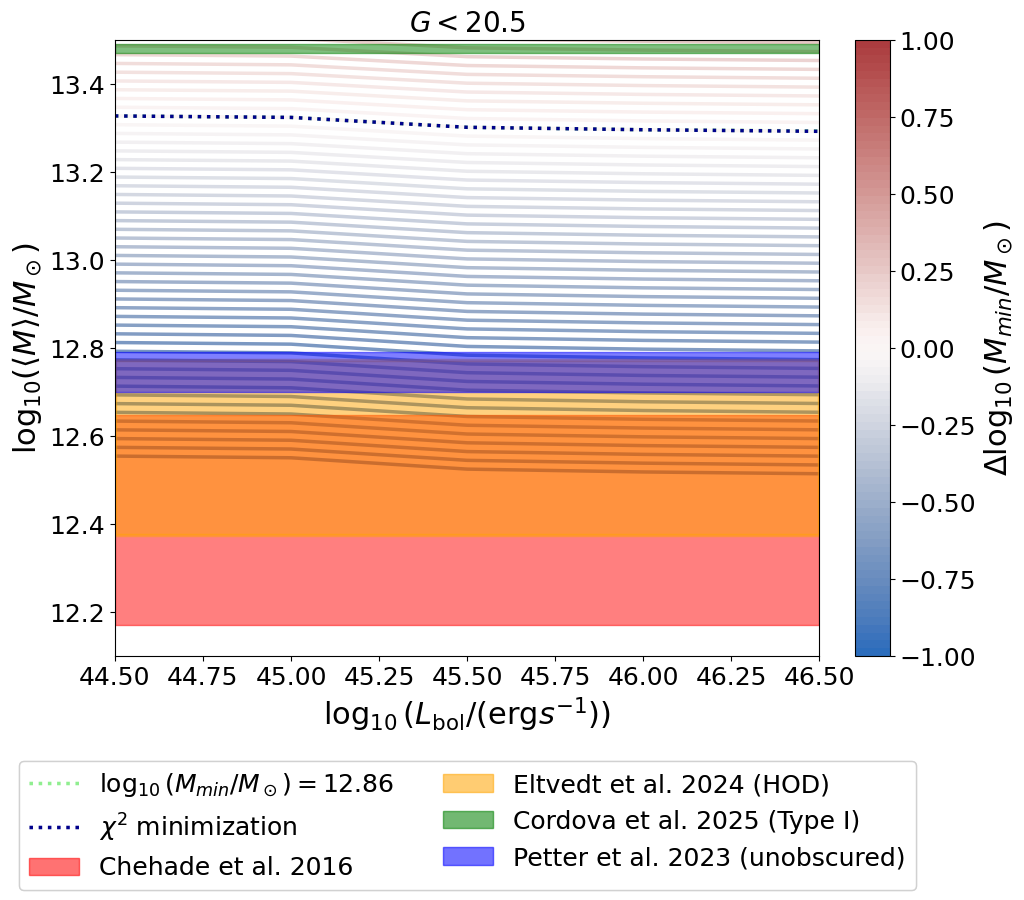

In [94]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    M_h = [M(np.logspace(np.log10(M_min_fit[j])-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*fduty_fit[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in range(len(L_bol))]
    ax1.plot(L_bol, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in range(len(L_bol))]
ax1.plot(L_bol, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), np.ones(np.shape(bins))*fduty_fit[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in range(len(L_bol))]
ax1.plot(L_bol, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.fill_between(L_bol, [np.log10(1e12/cosmo_planck18['h'])]*len(L_bol), [np.log10(3e12/cosmo_planck18['h'])]*len(L_bol), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(L_bol, [np.log10(1.6e12/cosmo_planck18['h'])]*len(L_bol), [np.log10(4e12/cosmo_planck18['h'])]*len(L_bol), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(L_bol, [13.47]*len(L_bol), [13.49]*len(L_bol), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(L_bol, [np.log10(10**12.53/cosmo_planck18['h'])]*len(L_bol), [np.log10(10**12.62/cosmo_planck18['h'])]*len(L_bol), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), '$\chi^2$ minimization',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.15), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(L_bol[0], L_bol[-1])
ax1.set_ylim(12.1, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [95]:
correction=np.array([])
for j in range(len(L_bol)):
    if j > 2:
        correction = np.append(correction, 1)
    else:
        correction = np.append(correction, np.min((N_q[j]/N_exp[j], 1)))

<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:86: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:86: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_22240/2611382762.py:35: SyntaxWarning: invalid escape sequence '\c'
  label = '$\chi^2$ minimization'),
/tmp/ipykernel_22240/2611382762.py:41: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
/tmp/ipykernel_22240/2611382762.py:46: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
/tmp/ipykernel_22240/2611382762.py:79: SyntaxWarning: invalid escape sequence '\l'
  a

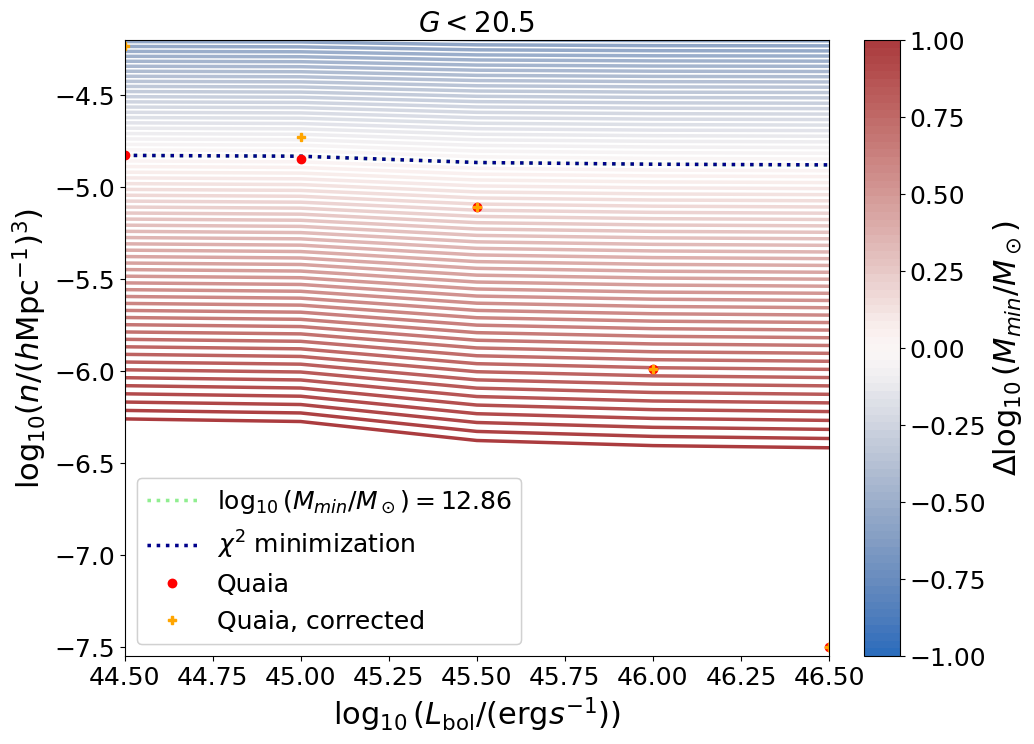

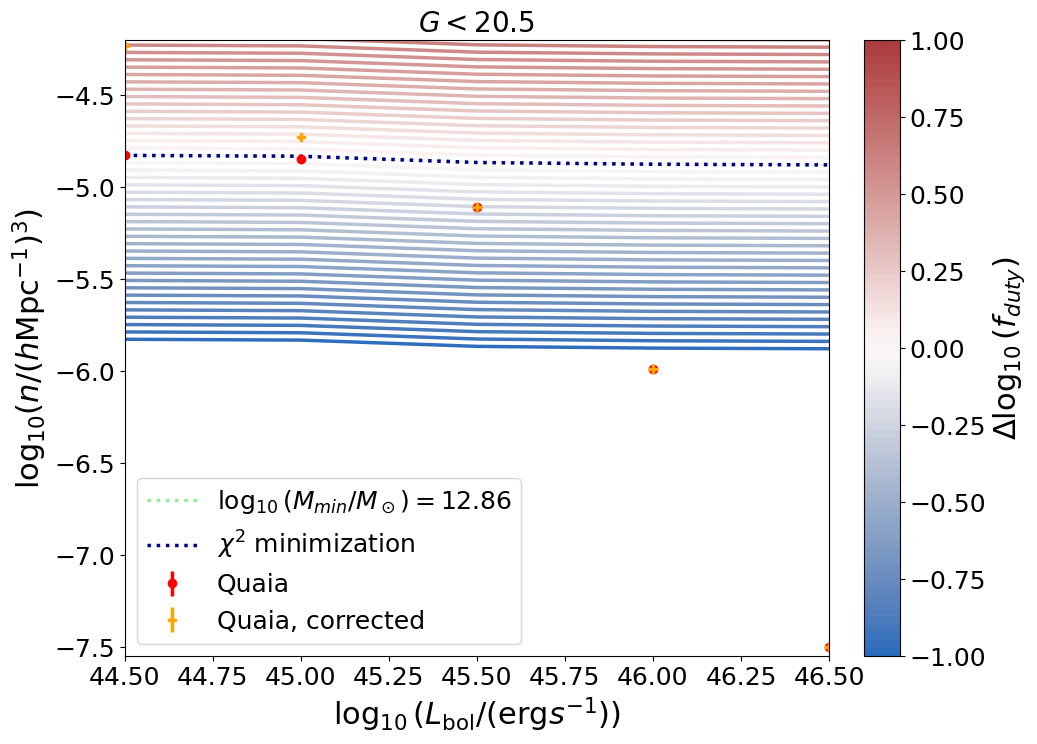

In [97]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
ylim = -7.55, -4.2

for k in range(len(bins)):
    
    n_q_theory = [M(np.logspace(np.log10(M_min_fit[j])-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*fduty_fit[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in range(len(L_bol))]
    ax1.plot(L_bol, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap_M_min[k])

n_q_theory, n_q_theory_fit = [], []
for j in range(len(L_bol)):
    
    n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    
    n_m=np.ones(np.shape(bins))*fduty_fit[j]
    n_q_theory_fit.append(M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])

ax1.plot(L_bol, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.plot(L_bol, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.errorbar(L_bol, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')
ax1.errorbar(L_bol, np.log10(n_q/correction), linewidth = 2.5, marker = 'P', label = 'Quaia, corrected', color = 'orange',
             yerr = [np.log10(n_q/correction)-np.log10(np.subtract(n_q/correction, n_q_err)), np.log10(np.add(n_q/correction, n_q_err))-np.log10(n_q/correction)], linestyle = 'None')

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_xlim(L_bol[0], L_bol[-1])

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = '$\chi^2$ minimization'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia'), 
                Line2D([0], [0], color = 'orange', marker = 'P', linestyle = 'None', linewidth = 2.5, label = 'Quaia, corrected')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1
l = 38

for k in range(len(fduty_array)):

    n_q_theory=[]
    for j in range(len(L_bol)):
        
        n_m = np.ones(np.shape(bins))*10**(np.log10(fduty_fit[j])-1+k/int(len(fduty_array)/2))
        n_q_theory.append(M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
        
    ax1.plot(L_bol, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty_k[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in range(len(L_bol))]
ax1.plot(L_bol, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])

ax1.plot(L_bol, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(L_bol, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')
ax1.errorbar(L_bol, np.log10(n_q/correction), linewidth = 2.5, marker = 'P', label = 'Quaia, corrected', color = 'orange',
             yerr = [np.log10(n_q/correction)-np.log10(np.subtract(n_q/correction, n_q_err)), np.log10(np.add(n_q/correction, n_q_err))-np.log10(n_q/correction)], linestyle = 'None')
ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$\log_{10}(L_\mathrm{bol}/(\mathrm{erg }s^{-1}))$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
ax1.legend()
ax1.set_xlim(L_bol[0], L_bol[-1])

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(f_{duty})$')
plt.show()